# Concept Alignment Figures

In [1]:
from pathlib import Path
import yaml
import numpy as np
from torch.utils.data import DataLoader

from torchvision.models import resnet18
import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger
from torch.nn import BCEWithLogitsLoss
from torch.utils.data import random_split, DataLoader
from pytorch_lightning.callbacks import ModelCheckpoint

from sklearn.metrics import roc_curve, auc, precision_score, recall_score
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import pandas as pd
from omegaconf import OmegaConf
from hydra.utils import instantiate
from typing import Sequence, Optional

import os
import torch
import sys
import pickle

sys.path.append(Path.cwd().parent.as_posix())

In [ ]:
from utils.cav import compute_cavs

def get_baseline_cavs(model_name:str, layer:str, dataset_name:str, cav_type:str) -> torch.Tensor:
    base_path = Path("/home/erogullari/Workspace/cav-disentanglement/variables")
    vars_path = base_path / dataset_name / f"{model_name}" / f"{layer}.pth"
    vars = torch.load(vars_path, map_location="cpu", weights_only=True)
    encs = vars['encs']
    labels = vars['labels']
    cavs, _ = compute_cavs(encs, labels, type=cav_type, normalize=True)
    return cavs

def _find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for cand in [start, *start.parents]:
        if (cand / "configs").exists() and (cand / "results").exists():
            return cand
    return start


def _format_run_value(value) -> str:
    if value is None:
        return "None"
    return f"{float(value):g}"


def _normalize_parameter_sequence(values):
    if isinstance(values, tuple) and len(values) == 1 and isinstance(values[0], (list, tuple)):
        return values[0]
    return values


def _alpha_beta_settings(alphas: Sequence[float], betas: Optional[Sequence[float]] = None) -> list[dict]:
    alphas = _normalize_parameter_sequence(alphas)
    betas = None if betas is None else _normalize_parameter_sequence(betas)
    if betas is not None and len(alphas) != len(betas):
        raise ValueError("alphas and betas must have the same length when betas are provided")

    settings = []
    for idx, alpha in enumerate(alphas):
        beta = None if betas is None else betas[idx]
        settings.append(
            {
                "x_pos": idx,
                "alpha": None if alpha is None else float(alpha),
                "alpha_str": _format_run_value(alpha),
                "beta": None if beta is None else float(beta),
                "beta_str": None if beta is None else _format_run_value(beta),
            }
        )
    return settings


def _alpha_beta_folder(alpha, beta, targets, learning_rate: str, run_suffix: str) -> str:
    folder = f"alpha{_format_run_value(alpha)}"
    if beta is not None:
        targets = _normalize_parameter_sequence(targets)
        if not targets:
            raise ValueError("targets must be provided when beta values are provided")
        folder += f"_beta{_format_run_value(beta)}_targets-{'-'.join(str(target) for target in targets)}"
    return f"{folder}_lr{learning_rate}{run_suffix}"


def _alpha_beta_axis(settings: Sequence[dict]) -> dict:
    has_beta = any(setting["beta"] is not None for setting in settings)
    if not has_beta:
        return {
            "labels": [setting["alpha_str"] for setting in settings],
            "xlabel": "alpha",
            "title_param": "alpha",
            "file_suffix": "over_alpha",
        }

    alpha_labels = {setting["alpha_str"] for setting in settings}
    if len(alpha_labels) == 1:
        alpha_label = next(iter(alpha_labels))
        return {
            "labels": [setting["beta_str"] for setting in settings],
            "xlabel": f"beta (alpha={alpha_label})",
            "title_param": "beta",
            "file_suffix": "over_beta",
        }

    return {
        "labels": [f"a={setting['alpha_str']}\nb={setting['beta_str']}" for setting in settings],
        "xlabel": "alpha / beta",
        "title_param": "alpha/beta",
        "file_suffix": "over_alpha_beta",
    }


def _parameterized_title(title: str, title_param: str) -> str:
    return title.replace("over alpha", f"over {title_param}")


def _parameterized_save_name(save_name: str, file_suffix: str) -> str:
    return save_name.replace("over_alpha", file_suffix)


/home/erogullari/miniconda3/envs/xai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Alignment over alpha/beta

In [3]:
def plot_concept_alignment_similarity_over_alpha(
    model: str = "vgg16",
    layer: str = "features.29",
    learning_rate: str = "0.0001",
    alphas: Sequence[float] = (0, 0.1, 1, 10, 100, 1000),
    concepts: tuple[str, str] = ("timestamp", "box"),
    results_root: Path = Path("results/concept_alignment"),
    save_root: Path = Path("media/concept_alignment"),
    run_suffix: str = "_opt",
):
    """Plot concept-alignment similarity over alpha for pattern vs multi-pattern CAVs.

    Reads: results/.../<cav_type>/alpha{alpha}_lr{learning_rate}{run_suffix}/results/alignment_summary.csv
    Saves: media/concept_alignment/similarity_over_alpha_line_<model>.png/.pdf
    """
    project_root = _find_project_root()
    results_root = results_root if results_root.is_absolute() else project_root / results_root
    save_root = save_root if save_root.is_absolute() else project_root / save_root

    cav_types = {
        "pattern": "pattern_cav",
        "multi-pattern": "multi_cav",
    }

    rows = []
    baseline_lookup = {}
    searched_paths = []
    for cav_label, cav_dir in cav_types.items():
        for alpha in alphas:
            alpha_str = f"{alpha:g}"
            summary_path = (
                results_root
                / model
                / layer
                / cav_dir
                / f"alpha{alpha_str}_lr{learning_rate}{run_suffix}"
                / "results"
                / "alignment_summary.csv"
            )
            searched_paths.append(summary_path)
            if not summary_path.exists():
                continue

            df = pd.read_csv(summary_path)
            if "concept" not in df.columns or "cosine_mean" not in df.columns:
                continue
            concept_col = df["concept"].astype(str).str.lower()
            model_col = (
                df["model"].astype(str).str.lower()
                if "model" in df.columns
                else pd.Series(["" for _ in range(len(df))], index=df.index)
            )
            for concept in concepts:
                concept_df = df.loc[concept_col == concept.lower()]
                if concept_df.empty:
                    continue
                baseline_df = concept_df.loc[model_col.loc[concept_df.index] == "baseline"]
                if not baseline_df.empty:
                    baseline_lookup[(cav_label, concept)] = float(baseline_df["cosine_mean"].mean())
                rows.append(
                    {
                        "alpha": float(alpha),
                        "concept": concept,
                        "cav_type": cav_label,
                        "similarity": float(concept_df["cosine_mean"].mean()),
                    }
                )

    plot_df = pd.DataFrame(rows)
    if plot_df.empty:
        discovered = sorted(results_root.glob("**/alignment_summary.csv"))
        msg = [
            "No concept-alignment results found for the provided settings.",
            f"Resolved results_root: {results_root}",
            "Sample searched paths:",
            *[f"  - {p}" for p in searched_paths[:6]],
            "Discovered alignment files:",
            *[f"  - {p}" for p in discovered[:12]],
        ]
        raise FileNotFoundError("\n".join(msg))

    # If alpha=0 is requested but missing on disk, backfill from Baseline model values.
    if any(float(a) == 0.0 for a in alphas):
        for cav_label in cav_types.keys():
            for concept in concepts:
                has_alpha0 = not plot_df.loc[
                    (plot_df["alpha"].eq(0.0))
                    & (plot_df["concept"] == concept)
                    & (plot_df["cav_type"] == cav_label)
                ].empty
                if has_alpha0:
                    continue
                key = (cav_label, concept)
                if key not in baseline_lookup:
                    continue
                plot_df = pd.concat(
                    [
                        plot_df,
                        pd.DataFrame(
                            [
                                {
                                    "alpha": 0.0,
                                    "concept": concept,
                                    "cav_type": cav_label,
                                    "similarity": float(baseline_lookup[key]),
                                }
                            ]
                        ),
                    ],
                    ignore_index=True,
                )

    fig, ax_left = plt.subplots(figsize=(8.5, 4.5))
    ax_right = ax_left.twinx()
    ax_left.grid(True, which="major", axis="both", alpha=0.35)

    alpha_order = [float(a) for a in alphas]
    alpha_labels = [f"{a:g}" for a in alpha_order]
    alpha_to_x = {label: idx for idx, label in enumerate(alpha_labels)}

    concept_to_axis = {
        concepts[0]: ax_left,
        concepts[1]: ax_right,
    }
    concept_to_color = {
        concepts[0]: "tab:blue",
        concepts[1]: "tab:orange",
    }
    cav_to_style = {
        "pattern": "-",
        "multi-pattern": "--",
    }

    for concept in concepts:
        for cav_label in cav_types.keys():
            series = plot_df.loc[
                (plot_df["concept"] == concept) & (plot_df["cav_type"] == cav_label)
            ].sort_values("alpha")
            if series.empty:
                continue
            series_x = series["alpha"].map(lambda v: alpha_to_x.get(f"{float(v):g}"))
            series = series.loc[series_x.notna()]
            series_x = series_x.loc[series_x.notna()]
            concept_to_axis[concept].plot(
                series_x,
                series["similarity"],
                linestyle=cav_to_style[cav_label],
                marker="o",
                color=concept_to_color[concept],
                label=f"{concept} ({cav_label})",
                linewidth=2,
                markersize=5,
            )

    # Equal spacing between alpha values
    ax_left.set_xlabel("alpha")
    ax_left.set_xticks(list(range(len(alpha_labels))))
    ax_left.set_xticklabels(alpha_labels)
    ax_left.set_ylabel(f"{concepts[0]} similarity", color=concept_to_color[concepts[0]])
    ax_right.set_ylabel(f"{concepts[1]} similarity", color=concept_to_color[concepts[1]])

    # Shared y-range for both y-axes
    y_min = float(plot_df["similarity"].min())
    y_max = float(plot_df["similarity"].max())
    y_pad = 0.05 if y_max == y_min else 0.05 * (y_max - y_min)
    y_low, y_high = y_min - y_pad, y_max + y_pad
    ax_left.set_ylim(y_low, y_high)
    ax_right.set_ylim(y_low, y_high)

    # Single legend with 4 combinations below the plot (2x2).
    left_handles, left_labels = ax_left.get_legend_handles_labels()
    right_handles, right_labels = ax_right.get_legend_handles_labels()
    all_handles = left_handles + right_handles
    all_labels = left_labels + right_labels
    dedup = dict(zip(all_labels, all_handles))
    legend_handles = []
    legend_labels = list(dedup.keys())
    for lbl in legend_labels:
        concept_match = next((c for c in concepts if lbl.startswith(f"{c} (")), concepts[0])
        cav_match = next((k for k in cav_types.keys() if f"({k})" in lbl), list(cav_types.keys())[0])
        legend_handles.append(
            Line2D(
                [0], [0],
                color=concept_to_color[concept_match],
                linestyle=cav_to_style[cav_match],
                linewidth=2,
            )
        )
    fig.subplots_adjust(bottom=0.28)
    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        ncol=2,
        bbox_to_anchor=(0.5, 0.02),
        frameon=True,
    )

    save_root.mkdir(parents=True, exist_ok=True)
    for ext in ["png", "pdf"]:
        fig.savefig(save_root / f"similarity_over_alpha_line_{model}.{ext}", bbox_inches="tight", dpi=300)
    plt.show()

    return plot_df


# Example call:
# df_plot = plot_concept_alignment_similarity_over_alpha()


In [4]:
def plot_artifact_similarity_over_alpha_beta(
    cav_types: Sequence[str] = ("pattern_cav", "multi_cav", "svm_cav", "log_cav", "random_cav"),
    artifact: str = "timestamp",
    alphas: Sequence[float] = (0, 0, 0, 0),
    betas: Optional[Sequence[float]] = None,
    targets: Optional[Sequence[str]] = None,
    model: str = "vgg16",
    layer: str = "features.29",
    learning_rate: str = "0.0001",
    results_root: Path = Path("results/concept_alignment"),
    save_root: Path = Path("media/concept_alignment"),
    run_suffix: str = "_opt",
):
    """Plot artifact cosine similarity over alpha or paired alpha/beta settings.

    Reads either:
      - results/.../<cav_type>/alpha{alpha}_lr{learning_rate}{run_suffix}/results/alignment_summary.csv
      - results/.../<cav_type>/alpha{alpha}_lr{learning_rate}{run_suffix}/results/alignment_per_sample.pkl
    or, when betas are provided:
      - results/.../<cav_type>/alpha{alpha}_beta{beta}_targets-{target1}-{target2}-..._lr{learning_rate}{run_suffix}/results/alignment_summary.csv
      - results/.../<cav_type>/alpha{alpha}_beta{beta}_targets-{target1}-{target2}-..._lr{learning_rate}{run_suffix}/results/alignment_per_sample.pkl
    Saves: media/concept_alignment/<artifact>_similarity_over_alpha|beta|alpha_beta_line_<model>.png/.pdf
    """
    project_root = _find_project_root()
    results_root = results_root if results_root.is_absolute() else project_root / results_root
    save_root = save_root if save_root.is_absolute() else project_root / save_root
    save_root = save_root / "alignment"
    settings = _alpha_beta_settings(alphas, betas)
    axis_info = _alpha_beta_axis(settings)

    rows = []
    raw_rows = []
    baseline_lookup = {}
    baseline_sem_lookup = {}
    searched_paths = []

    for cav_type in cav_types:
        for setting in settings:
            summary_path = (
                results_root
                / model
                / layer
                / cav_type
                / _alpha_beta_folder(setting["alpha"], setting["beta"], targets, learning_rate, run_suffix)
                / "results"
                / "alignment_summary.csv"
            )
            searched_paths.append(summary_path)
            if not summary_path.exists():
                continue

            df = pd.read_csv(summary_path)
            if "concept" not in df.columns or "cosine_mean" not in df.columns:
                continue

            concept_df = df.loc[df["concept"].astype(str).str.lower() == artifact.lower()]
            if concept_df.empty:
                continue

            if "model" in concept_df.columns:
                model_col = concept_df["model"].astype(str).str.lower()
                baseline_df = concept_df.loc[model_col == "baseline"]
                orth_df = concept_df.loc[model_col == "orthogonal"]
            else:
                baseline_df = pd.DataFrame()
                orth_df = concept_df

            if not baseline_df.empty:
                baseline_lookup[cav_type] = float(baseline_df["cosine_mean"].mean())
                if "cosine_sem" in baseline_df.columns:
                    baseline_sem_lookup[cav_type] = float(baseline_df["cosine_sem"].mean())

            if orth_df.empty:
                continue

            row = {
                "x_pos": setting["x_pos"],
                "alpha": setting["alpha"],
                "alpha_str": setting["alpha_str"],
                "beta": setting["beta"],
                "beta_str": setting["beta_str"],
                "cav_type": cav_type,
                "similarity": float(orth_df["cosine_mean"].mean()),
            }
            if "cosine_sem" in orth_df.columns:
                row["similarity_sem"] = float(orth_df["cosine_sem"].mean())
            rows.append(row)

            per_sample_path = summary_path.parent / "alignment_per_sample.pkl"
            if per_sample_path.exists():
                per_sample = pd.read_pickle(per_sample_path)
                artifact_scores = per_sample.get(artifact) if isinstance(per_sample, dict) else None
                if isinstance(artifact_scores, dict):
                    if setting["beta"] is None and setting["alpha"] == 0.0 and "Baseline" in artifact_scores:
                        for score in artifact_scores["Baseline"]:
                            raw_rows.append(
                                {
                                    "x_pos": setting["x_pos"],
                                    "alpha": 0.0,
                                    "alpha_str": "0",
                                    "beta": None,
                                    "beta_str": None,
                                    "cav_type": cav_type,
                                    "similarity": float(score),
                                }
                            )
                    if "Orthogonal" in artifact_scores:
                        for score in artifact_scores["Orthogonal"]:
                            raw_rows.append(
                                {
                                    "x_pos": setting["x_pos"],
                                    "alpha": setting["alpha"],
                                    "alpha_str": setting["alpha_str"],
                                    "beta": setting["beta"],
                                    "beta_str": setting["beta_str"],
                                    "cav_type": cav_type,
                                    "similarity": float(score),
                                }
                            )

    plot_df = pd.DataFrame(rows)

    # Backfill only the plain alpha=0 baseline setting. Beta sweeps with alpha=0 are real runs.
    for setting in settings:
        if setting["beta"] is not None or setting["alpha"] != 0.0:
            continue
        for cav_type in cav_types:
            has_setting = (
                not plot_df.loc[
                    (plot_df["x_pos"].eq(setting["x_pos"])) & (plot_df["cav_type"] == cav_type)
                ].empty
                if not plot_df.empty
                else False
            )
            if has_setting or cav_type not in baseline_lookup:
                continue
            plot_df = pd.concat(
                [
                    plot_df,
                    pd.DataFrame(
                        [
                            {
                                "x_pos": setting["x_pos"],
                                "alpha": 0.0,
                                "alpha_str": "0",
                                "beta": None,
                                "beta_str": None,
                                "cav_type": cav_type,
                                "similarity": float(baseline_lookup[cav_type]),
                                "similarity_sem": float(baseline_sem_lookup.get(cav_type, 0.0)),
                            }
                        ]
                    ),
                ],
                ignore_index=True,
            )

    if plot_df.empty:
        discovered = sorted(results_root.glob("**/alignment_summary.csv"))
        msg = [
            "No concept-alignment results found for the provided settings.",
            f"Resolved results_root: {results_root}",
            "Sample searched paths:",
            *[f"  - {p}" for p in searched_paths[:8]],
            "Discovered alignment files:",
            *[f"  - {p}" for p in discovered[:12]],
        ]
        raise FileNotFoundError("\n".join(msg))

    raw_plot_df = pd.DataFrame(raw_rows).drop_duplicates()
    if not raw_plot_df.empty:
        raw_plot_df = raw_plot_df.loc[raw_plot_df["x_pos"].isin(range(len(settings)))].copy()

    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    ax.grid(True, which="major", axis="both", alpha=0.35)

    colors = plt.rcParams["axes.prop_cycle"].by_key().get(
        "color", ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    )
    legend_handles = []
    legend_labels = []

    for idx, cav_type in enumerate(cav_types):
        color = colors[idx % len(colors)]
        linestyle = "-"
        raw_series = raw_plot_df.loc[raw_plot_df["cav_type"] == cav_type] if not raw_plot_df.empty else pd.DataFrame()

        if not raw_series.empty:
            sns.lineplot(
                data=raw_series,
                x="x_pos",
                y="similarity",
                ax=ax,
                color=color,
                linestyle=linestyle,
                marker="o",
                linewidth=2,
                markersize=5,
                errorbar="se",
                err_style="band",
                legend=False,
                zorder=3,
            )
        else:
            series = plot_df.loc[plot_df["cav_type"] == cav_type].sort_values("x_pos")
            if series.empty:
                continue
            yerr = series["similarity_sem"].fillna(0.0) if "similarity_sem" in series else None
            if yerr is not None:
                ax.fill_between(
                    series["x_pos"],
                    series["similarity"] - yerr,
                    series["similarity"] + yerr,
                    color=color,
                    alpha=0.16,
                    linewidth=0,
                )
            sns.lineplot(
                data=series,
                x="x_pos",
                y="similarity",
                ax=ax,
                color=color,
                linestyle=linestyle,
                marker="o",
                linewidth=2,
                markersize=5,
                errorbar=None,
                legend=False,
                zorder=3,
            )

        legend_handles.append(Line2D([0], [0], color=color, linestyle=linestyle, linewidth=2))
        legend_labels.append(cav_type)

    ax.set_xlabel(axis_info["xlabel"])
    ax.set_xticks(list(range(len(axis_info["labels"]))))
    ax.set_xticklabels(axis_info["labels"])
    ax.set_ylabel(f"{artifact} similarity")
    ax.set_title(f"{artifact} alignment over {axis_info['title_param']}")

    if "similarity_sem" in plot_df:
        y_lower = plot_df["similarity"] - plot_df["similarity_sem"].fillna(0.0)
        y_upper = plot_df["similarity"] + plot_df["similarity_sem"].fillna(0.0)
    else:
        y_lower = plot_df["similarity"]
        y_upper = plot_df["similarity"]
    y_min = float(y_lower.min())
    y_max = float(y_upper.max())
    y_pad = 0.05 if y_max == y_min else 0.05 * (y_max - y_min)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    fig.subplots_adjust(bottom=0.25)
    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        ncol=2,
        bbox_to_anchor=(0.5, 0.02),
        frameon=True,
    )

    save_root.mkdir(parents=True, exist_ok=True)
    fname = f"{artifact}_similarity_{axis_info['file_suffix']}_line"
    for ext in ["png", "pdf"]:
        fig.savefig(save_root / f"{fname}_{model}.{ext}", bbox_inches="tight", dpi=300)
    plt.show()

    return plot_df


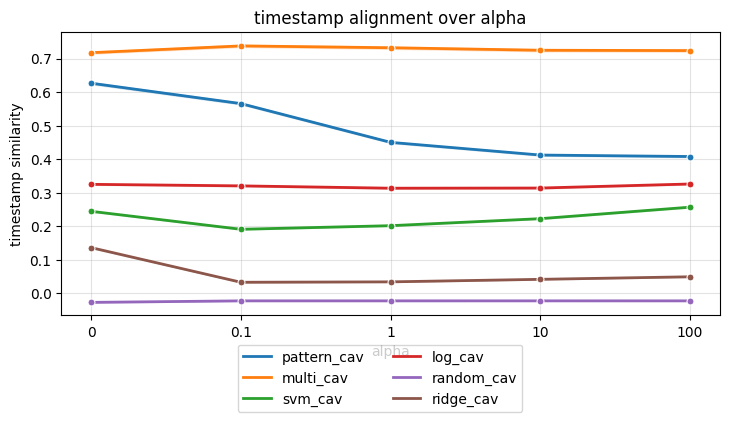

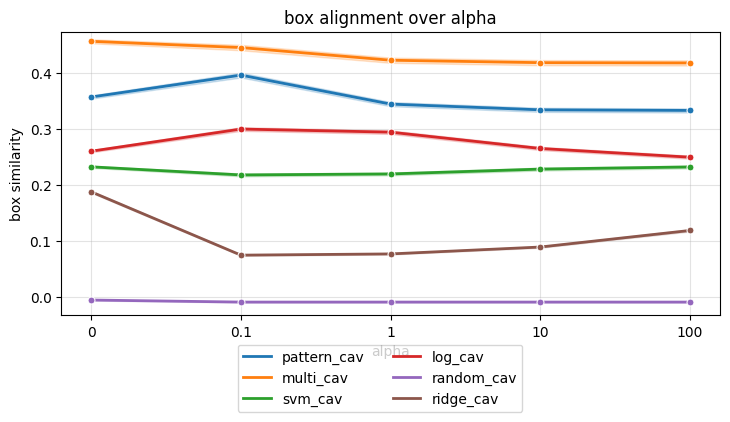

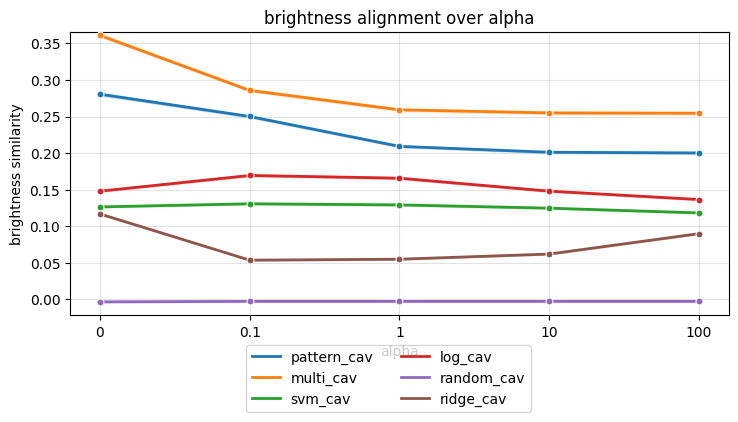

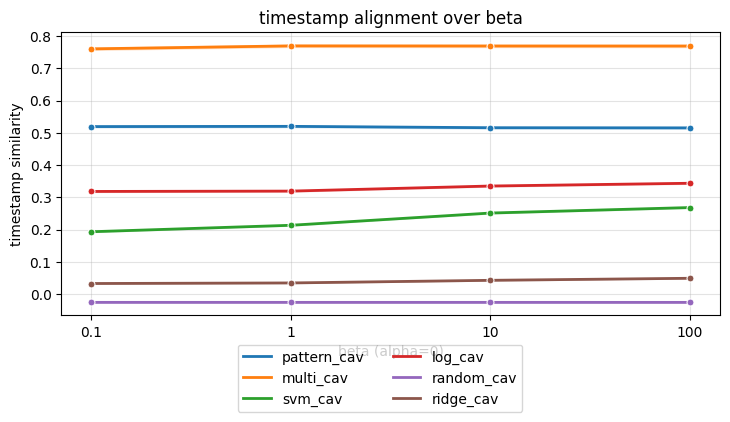

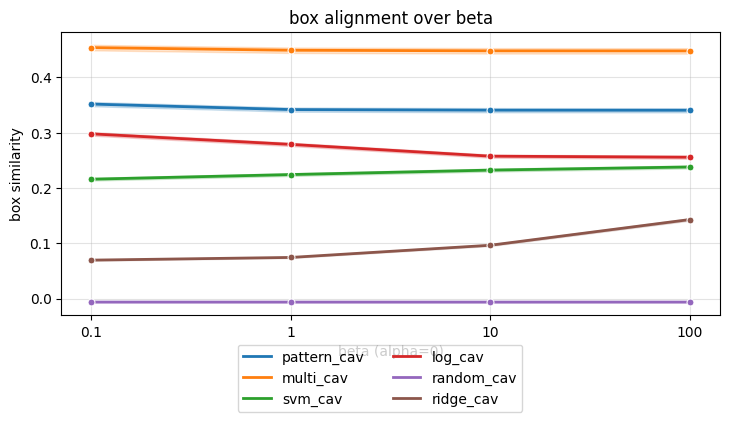

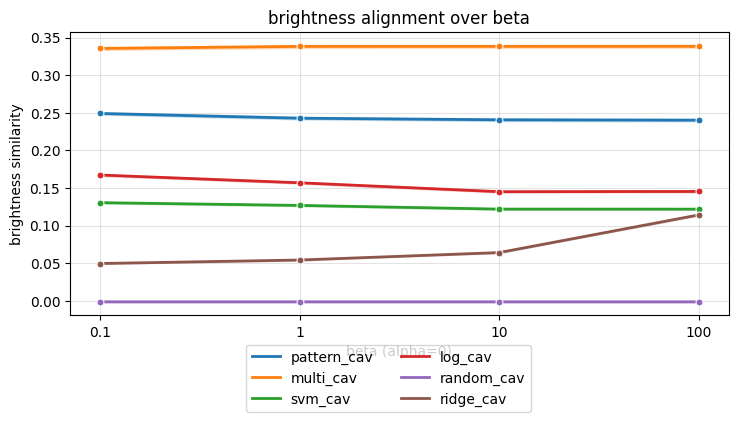

In [7]:
# VGG16
cav_types=("pattern_cav", "multi_cav", "svm_cav", "log_cav", "random_cav", "ridge_cav")
targets=("timestamp", "box", "brightness")
model="vgg16"
layer="features.29"

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=(0, 0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="box",
    alphas=(0, 0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="brightness",
    alphas=(0, 0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=(0, 0, 0, 0),
    betas=(0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="box",
    alphas=(0, 0, 0, 0),
    betas=(0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="brightness",
    alphas=(0, 0, 0, 0),
    betas=(0.1, 1, 10, 100),
    targets=targets,
)

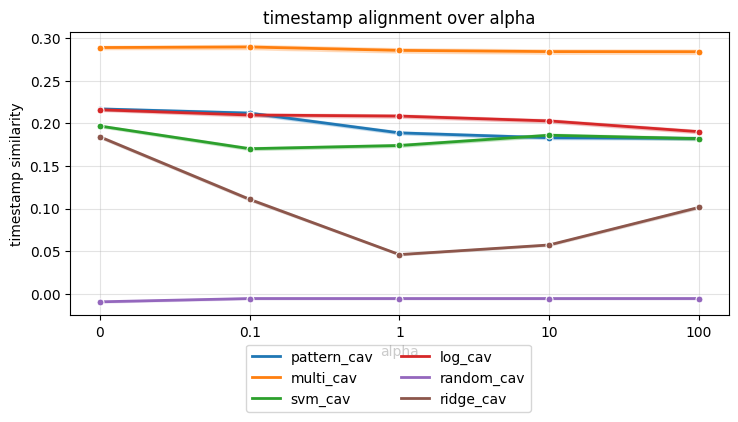

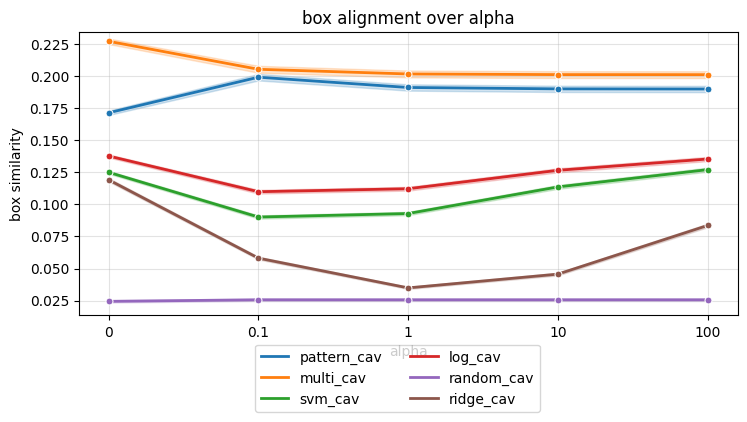

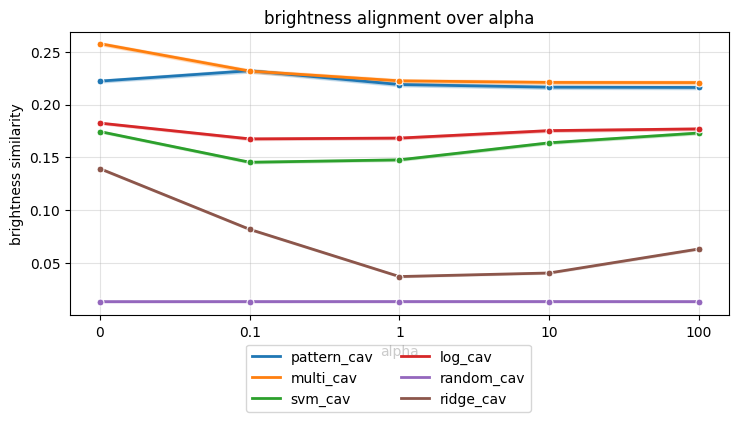

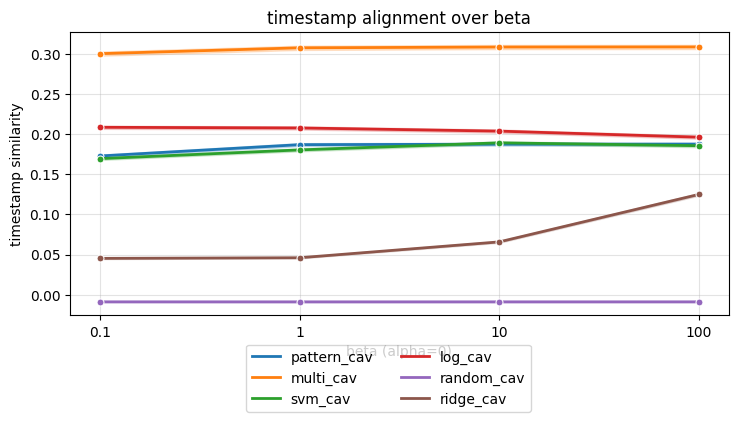

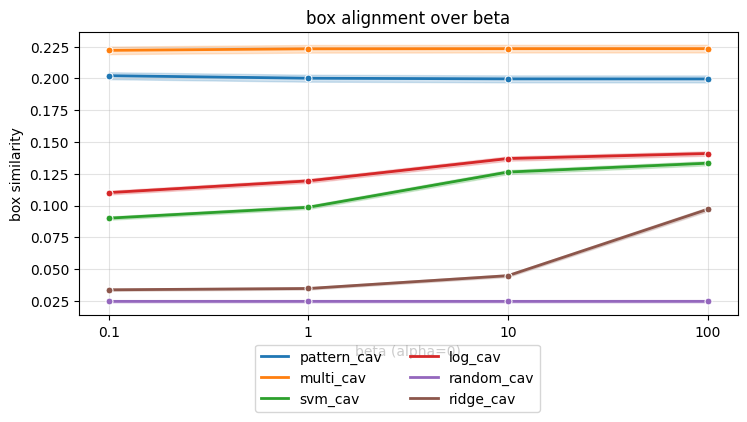

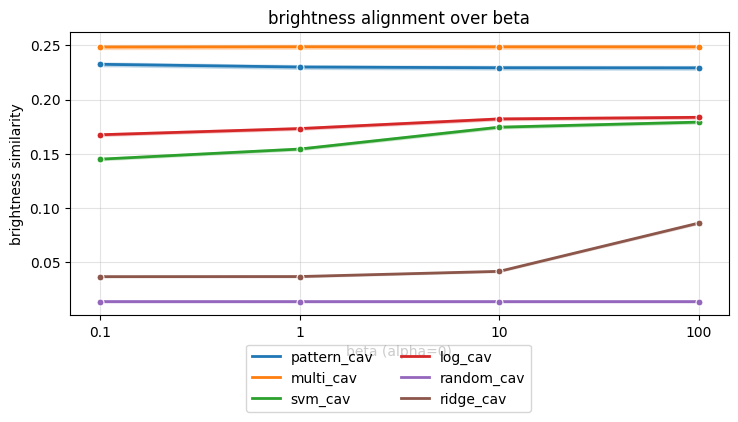

In [8]:
# Resnet18
cav_types=("pattern_cav", "multi_cav", "svm_cav", "log_cav", "random_cav", "ridge_cav")
targets=("timestamp", "box", "brightness")
model="resnet18"
layer="last_conv"

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=(0, 0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="box",
    alphas=(0, 0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="brightness",
    alphas=(0, 0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=(0, 0, 0, 0),
    betas=(0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="box",
    alphas=(0, 0, 0, 0),
    betas=(0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="brightness",
    alphas=(0, 0, 0, 0),
    betas=(0.1, 1, 10, 100),
    targets=targets,
)

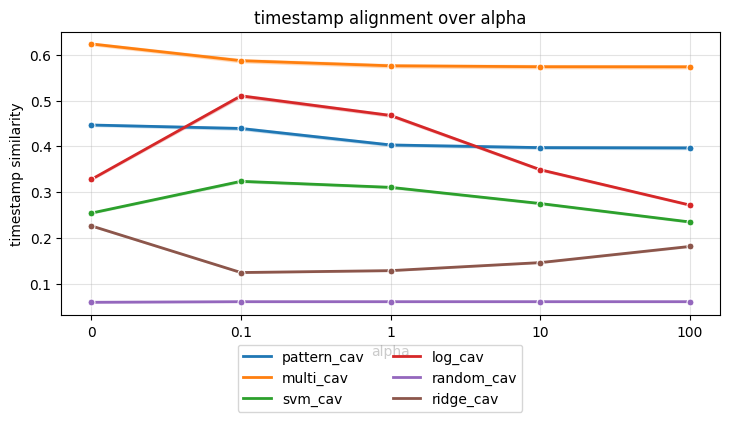

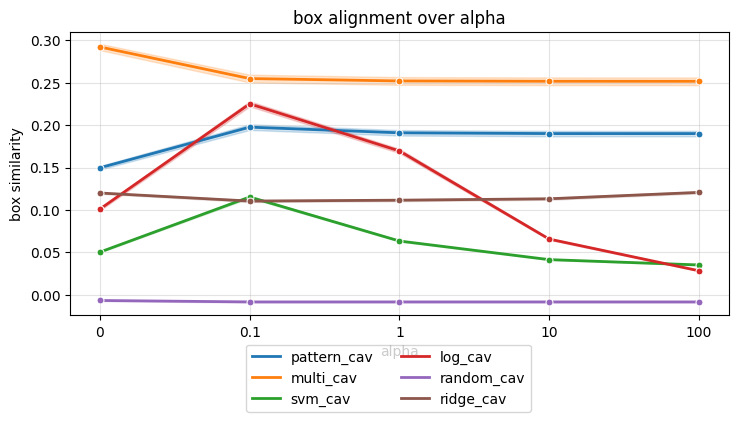

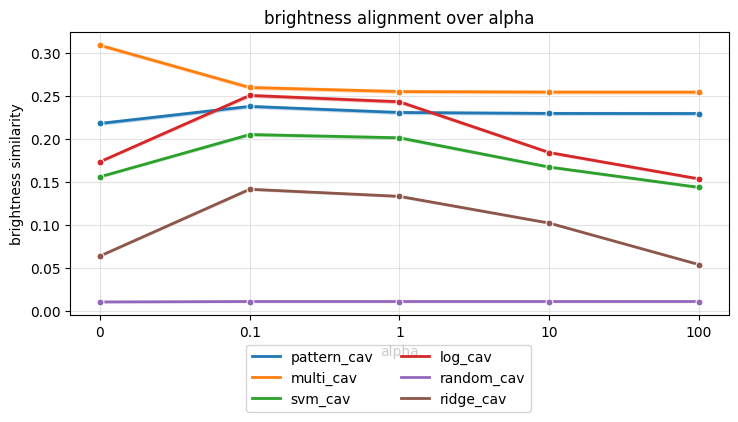

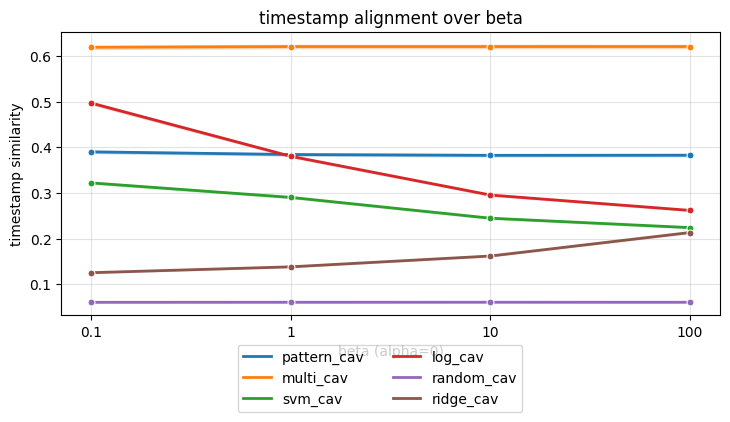

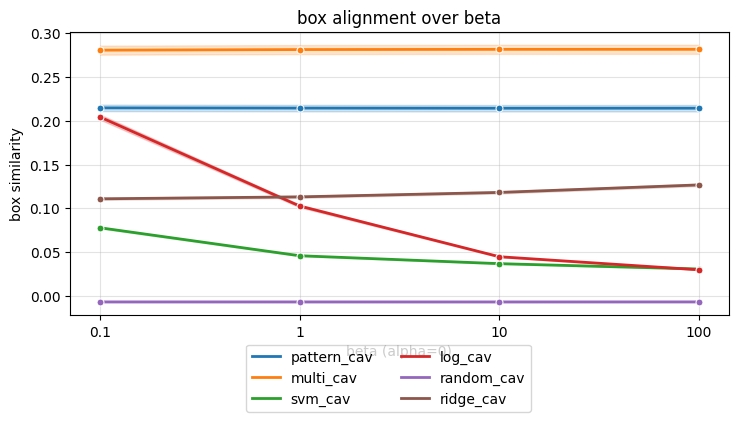

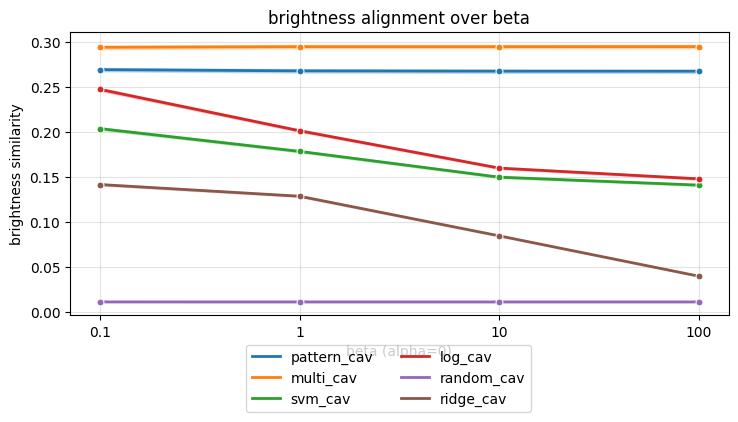

In [9]:
# ViT_b_16
cav_types=("pattern_cav", "multi_cav", "svm_cav", "log_cav", "random_cav", "ridge_cav")
targets=("timestamp", "box", "brightness")
model="vit_b_16"
layer="inspection_layer"

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=(0, 0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="box",
    alphas=(0, 0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="brightness",
    alphas=(0, 0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=(0, 0, 0, 0),
    betas=(0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="box",
    alphas=(0, 0, 0, 0),
    betas=(0.1, 1, 10, 100),
    targets=targets,
)

plot_df = plot_artifact_similarity_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="brightness",
    alphas=(0, 0, 0, 0),
    betas=(0.1, 1, 10, 100),
    targets=targets,
)

## Localization

In [10]:
def plot_artifact_localization_over_alpha_beta(
    cav_types: Sequence[str] = ("pattern_cav", "multi_cav", "svm_cav", "log_cav", "random_cav"),
    artifact: str = "timestamp",
    alphas: Sequence[float] = (0, 0.1, 1, 10, 100, 1000),
    betas: Optional[Sequence[float]] = None,
    targets: Optional[Sequence[str]] = None,
    model: str = "vgg16",
    layer: str = "features.29",
    learning_rate: str = "0.0001",
    metric_prefix: str = "concept_rel",
    model_key: str = "Orthogonal",
    baseline_key: str = "Baseline",
    use_cleaned_cavs: bool = False,
    value_column: str = "localization",
    metric_name: str = "localization",
    ylabel_template: str = "{artifact} localization (concept relevance)",
    title_template: str = "{artifact} localization over alpha",
    save_name_template: str = "{artifact}_localization_over_alpha_line",
    results_root: Path = Path("results/concept_alignment"),
    save_root: Path = Path("media/concept_alignment"),
    run_suffix: str = "_opt",
):
    """Plot an artifact metric over alpha or paired alpha/beta settings.

    Reads either:
      - results/.../<cav_type>/alpha{alpha}_lr{learning_rate}{run_suffix}/results/concept_relevance.pkl
    or, when betas are provided:
      - results/.../<cav_type>/alpha{alpha}_beta{beta}_targets-{target1}-{target2}-..._lr{learning_rate}{run_suffix}/results/concept_relevance.pkl
    Saves: media/concept_alignment/<save_name_template>_<model>.png/.pdf
    """
    project_root = _find_project_root()
    results_root = results_root if results_root.is_absolute() else project_root / results_root
    save_root = save_root if save_root.is_absolute() else project_root / save_root
    save_root = save_root / "localization"
    settings = _alpha_beta_settings(alphas, betas)
    axis_info = _alpha_beta_axis(settings)

    if use_cleaned_cavs:
        model_key = model_key if model_key.endswith(" Cleaned") else f"{model_key} Cleaned"
        baseline_key = baseline_key if baseline_key.endswith(" Cleaned") else f"{baseline_key} Cleaned"

    target_key = f"{metric_prefix}_{artifact}_{model_key}"
    target_sem_key = f"{target_key}_sem"
    baseline_metric_key = f"{metric_prefix}_{artifact}_{baseline_key}"
    baseline_sem_key = f"{baseline_metric_key}_sem"

    rows = []
    baseline_lookup = {}
    baseline_sem_lookup = {}
    sem_column = f"{value_column}_sem"
    searched_paths = []

    for cav_type in cav_types:
        for setting in settings:
            metrics_path = (
                results_root
                / model
                / layer
                / cav_type
                / _alpha_beta_folder(setting["alpha"], setting["beta"], targets, learning_rate, run_suffix)
                / "results"
                / "concept_relevance.pkl"
            )
            searched_paths.append(metrics_path)
            if not metrics_path.exists():
                continue

            metrics = pd.read_pickle(metrics_path)
            if not isinstance(metrics, dict):
                continue

            if baseline_metric_key in metrics:
                baseline_lookup[cav_type] = float(metrics[baseline_metric_key])
                if baseline_sem_key in metrics:
                    baseline_sem_lookup[cav_type] = float(metrics[baseline_sem_key])

            if target_key not in metrics:
                continue

            row = {
                "x_pos": setting["x_pos"],
                "alpha": setting["alpha"],
                "alpha_str": setting["alpha_str"],
                "beta": setting["beta"],
                "beta_str": setting["beta_str"],
                "cav_type": cav_type,
                value_column: float(metrics[target_key]),
            }
            if target_sem_key in metrics:
                row[sem_column] = float(metrics[target_sem_key])
            rows.append(row)

    plot_df = pd.DataFrame(rows)

    # Backfill only the plain alpha=0 baseline setting. Beta sweeps with alpha=0 are real runs.
    for setting in settings:
        if setting["beta"] is not None or setting["alpha"] != 0.0:
            continue
        for cav_type in cav_types:
            has_setting = (
                not plot_df.loc[
                    (plot_df["x_pos"].eq(setting["x_pos"])) & (plot_df["cav_type"] == cav_type)
                ].empty
                if not plot_df.empty
                else False
            )
            if has_setting or cav_type not in baseline_lookup:
                continue
            plot_df = pd.concat(
                [
                    plot_df,
                    pd.DataFrame(
                        [
                            {
                                "x_pos": setting["x_pos"],
                                "alpha": 0.0,
                                "alpha_str": "0",
                                "beta": None,
                                "beta_str": None,
                                "cav_type": cav_type,
                                value_column: float(baseline_lookup[cav_type]),
                                sem_column: float(baseline_sem_lookup.get(cav_type, 0.0)),
                            }
                        ]
                    ),
                ],
                ignore_index=True,
            )

    if plot_df.empty:
        discovered = sorted(results_root.glob("**/concept_relevance.pkl"))
        msg = [
            f"No {metric_name} results found for the provided settings.",
            f"Resolved results_root: {results_root}",
            "Sample searched paths:",
            *[f"  - {p}" for p in searched_paths[:8]],
            "Discovered metric files:",
            *[f"  - {p}" for p in discovered[:12]],
        ]
        raise FileNotFoundError("\n".join(msg))

    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    ax.grid(True, which="major", axis="both", alpha=0.35)

    colors = plt.rcParams["axes.prop_cycle"].by_key().get(
        "color", ["tab:blue", "tab:orange", "tab:green", "tab:red"]
    )
    legend_handles = []
    legend_labels = []

    for idx, cav_type in enumerate(cav_types):
        series = plot_df.loc[plot_df["cav_type"] == cav_type].sort_values("x_pos")
        if series.empty:
            continue

        color = colors[idx % len(colors)]
        linestyle = "-"

        yerr = series[sem_column].fillna(0.0) if sem_column in series else None
        if yerr is not None:
            ax.fill_between(
                series["x_pos"],
                series[value_column] - yerr,
                series[value_column] + yerr,
                color=color,
                alpha=0.16,
                linewidth=0,
            )
        sns.lineplot(
            data=series,
            x="x_pos",
            y=value_column,
            ax=ax,
            color=color,
            linestyle=linestyle,
            marker="o",
            linewidth=2,
            markersize=5,
            errorbar=None,
            legend=False,
            zorder=3,
        )

        legend_handles.append(Line2D([0], [0], color=color, linestyle=linestyle, linewidth=2))
        legend_labels.append(cav_type)

    ax.set_xlabel(axis_info["xlabel"])
    ax.set_xticks(list(range(len(axis_info["labels"]))))
    ax.set_xticklabels(axis_info["labels"])
    ax.set_ylabel(ylabel_template.format(artifact=artifact))
    title = title_template.format(artifact=artifact)
    if use_cleaned_cavs:
        title += " (cleaned CAVs)"
    ax.set_title(_parameterized_title(title, axis_info["title_param"]))

    if sem_column in plot_df:
        y_lower = plot_df[value_column] - plot_df[sem_column].fillna(0.0)
        y_upper = plot_df[value_column] + plot_df[sem_column].fillna(0.0)
    else:
        y_lower = plot_df[value_column]
        y_upper = plot_df[value_column]
    y_min = float(y_lower.min())
    y_max = float(y_upper.max())
    y_pad = 0.05 if y_max == y_min else 0.05 * (y_max - y_min)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    fig.subplots_adjust(bottom=0.25)
    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        ncol=2,
        bbox_to_anchor=(0.5, 0.02),
        frameon=True,
    )

    save_root.mkdir(parents=True, exist_ok=True)
    fname = save_name_template.format(artifact=artifact)
    fname = _parameterized_save_name(fname, axis_info["file_suffix"])
    if use_cleaned_cavs:
        fname += "_cleaned"
    for ext in ["png", "pdf"]:
        fig.savefig(save_root / f"{fname}_{model}.{ext}", bbox_inches="tight", dpi=300)
    plt.show()

    return plot_df


def display_artifact_localization_over_alpha_beta(
    sample_id: int,
    cav_types: Sequence[str] = ("pattern_cav", "multi_cav", "svm_cav", "log_cav", "g_sae"),
    artifact: str = "timestamp",
    alphas: Sequence[float] = (0, 0.1, 1, 10, 100, 1000),
    betas: Optional[Sequence[float]] = None,
    targets: Optional[Sequence[str]] = None,
    model: str = "vgg16",
    layer: str = "features.29",
    learning_rate: str = "0.0001",
    concept_alignment_config: str = "concept_alignment",
    results_root: Path = Path("results/concept_alignment"),
    variables_root: Path = Path("variables"),
    save_root: Path | None = Path("media/concept_alignment"),
    run_suffix: str = "_opt",
    device: str = "cpu",
    cmap: str = "bwr",
    heatmap_normalization: str = "global",
    level: float = 2.0,
    use_cleaned_cavs: bool = False,
    show_localization_scores: bool = False,
    localization_score_artifact: Optional[str] = None,
):
    """Display CRP/LRP localization examples for one sample over CAV type and alpha/beta.

    Rows are CAV types and columns are alpha or paired alpha/beta settings. Plain alpha=0
    loads the baseline CAV cached in variables/.../<layer>/<cav_type>.pth. When beta is
    provided, even alpha=0 loads results/.../alpha0_beta{beta}_targets-.../cavs.pt.
    Set use_cleaned_cavs=True to project the target concept's non-concept mean out
    of every loaded CAV before computing its LRP heatmap. Set
    show_localization_scores=True to annotate each panel with the selected sample's
    concept-relevance localization metric. localization_score_artifact can select
    a related metric key, such as box_dilated_3px for a box concept heatmap.
    """
    import hydra
    import torch
    from crp.attribution import CondAttribution
    from crp.image import imgify
    from hydra.core.global_hydra import GlobalHydra
    from omegaconf import OmegaConf
    from zennit.composites import EpsilonPlusFlat

    from datasets import get_dataset
    from experiments.model_correction.evaluate_heatmaps import (
        BOX_DILATED_CONCEPT_NAME,
        BOX_MASK_DILATION_PIXELS,
        _clean_cav,
        _dilate_binary_masks,
    )
    from models import get_canonizer, get_fn_model_loader, requires_lxt_localization
    from utils.localization import compute_concept_relevance, get_localizations

    project_root = _find_project_root()
    results_root = results_root if results_root.is_absolute() else project_root / results_root
    variables_root = variables_root if variables_root.is_absolute() else project_root / variables_root
    if save_root is not None:
        save_root = save_root if save_root.is_absolute() else project_root / save_root
        save_root = save_root / "heatmaps"
    settings = _alpha_beta_settings(alphas, betas)
    axis_info = _alpha_beta_axis(settings)

    cav_dir_aliases = {
        "g_sae": "G_SAE",
        "G_SAE": "G_SAE",
        "g_sae-topk0.25": "G_SAE-topk0.25",
        "random_cav": "random_cav",
    }

    def _cav_dir(cav_type: str) -> str:
        candidate = cav_dir_aliases.get(cav_type, cav_type)
        if (results_root / model / layer / candidate).exists():
            return candidate
        for fallback in [cav_type, cav_type.upper(), cav_type.lower()]:
            if (results_root / model / layer / fallback).exists():
                return fallback
        return candidate

    def _load_base_model(cfg, num_classes, device):
        model_loader = get_fn_model_loader(cfg.model.name)
        model = model_loader(
            n_class=num_classes,
            ckpt_path=getattr(cfg.model, "ckpt_path", None),
            pretrained=getattr(cfg.model, "pretrained", True),
        ).to(device)
        model.eval()
        return model

    def _baseline_cache_path(cav_type: str) -> Path:
        cav_dir = _cav_dir(cav_type)
        candidates = [
            variables_root / cfg.dataset.name / model / layer / f"{cav_dir}.pth",
            variables_root / cfg.dataset.name / model / layer / f"{cav_type}.pth",
        ]
        if cav_type == "random_cav":
            candidates.insert(0, variables_root / cfg.dataset.name / model / layer / "random_cav_seed42.pth")
        for candidate in candidates:
            if candidate.exists():
                return candidate
        return candidates[0]

    def _load_baseline_cavs(cav_type: str) -> torch.Tensor:
        cache_path = _baseline_cache_path(cav_type)
        payload = torch.load(cache_path, map_location="cpu", weights_only=True)
        if isinstance(payload, torch.Tensor):
            return payload
        entries = payload.get("entries", {}) if isinstance(payload, dict) else {}
        for entry_name in ["normalized", "unnormalized"]:
            entry = entries.get(entry_name)
            if isinstance(entry, dict) and "cavs" in entry:
                return entry["cavs"]
        raise ValueError(f"Could not find CAVs in baseline cache: {cache_path}")

    def _load_cavs(cav_type: str, setting: dict) -> torch.Tensor:
        if setting["beta"] is None and setting["alpha"] == 0.0:
            return _load_baseline_cavs(cav_type)
        cav_path = (
            results_root
            / model
            / layer
            / _cav_dir(cav_type)
            / _alpha_beta_folder(setting["alpha"], setting["beta"], targets, learning_rate, run_suffix)
            / "cavs.pt"
        )
        if not cav_path.exists():
            raise FileNotFoundError(cav_path)
        return torch.load(cav_path, map_location="cpu", weights_only=True)

    def _heatmap_key(cav_type: str, setting: dict):
        if setting["beta"] is None:
            return (cav_type, setting["alpha"])
        return (cav_type, setting["alpha"], setting["beta"])

    if GlobalHydra.instance().is_initialized():
        GlobalHydra.instance().clear()
    with hydra.initialize_config_dir(config_dir=str(project_root / "configs"), version_base=None):
        cfg = hydra.compose(
            config_name=concept_alignment_config,
            overrides=[
                f"model={model}",
                f"cav.layer={layer}",
                f"cav.alpha={settings[0]['alpha_str']}",
                f"train.learning_rate={learning_rate}",
            ],
        )
    OmegaConf.set_struct(cfg, False)
    cfg.train.device = str(device)

    dataset = get_dataset(cfg.dataset.name + "_hm")(**cfg.dataset)
    concept_names = dataset.get_concept_names()
    if artifact not in concept_names:
        raise ValueError(f"Unknown artifact/concept '{artifact}'. Available: {concept_names}")
    concept_idx = concept_names.index(artifact)

    non_concept_mean = None
    if use_cleaned_cavs:
        activations_path = variables_root / cfg.dataset.name / model / f"{layer}.pth"
        if not activations_path.exists():
            raise FileNotFoundError(f"Cached preprocessing data not found: {activations_path}")
        preprocessing = torch.load(activations_path, map_location="cpu", weights_only=True)
        if not isinstance(preprocessing, dict) or not {"encs", "labels"}.issubset(preprocessing):
            raise ValueError(f"Expected encs and labels in preprocessing cache: {activations_path}")
        activations = preprocessing["encs"]
        labels = preprocessing["labels"]
        if activations.ndim != 2 or labels.ndim != 2 or activations.shape[0] != labels.shape[0]:
            raise ValueError("Cached activations and labels must be aligned 2D tensors.")
        if concept_idx >= labels.shape[1]:
            raise ValueError(f"No label column available for concept '{artifact}'.")
        non_concept_mask = labels[:, concept_idx] == 0
        if not non_concept_mask.any():
            raise ValueError(f"No non-concept samples are available for concept '{artifact}'.")
        non_concept_mean = activations[non_concept_mask].mean(dim=0)

    sample = dataset[int(sample_id)]
    x = sample[0]
    if len(sample) < 3:
        raise ValueError("Heatmap dataset items must include artifact masks.")
    artifact_masks = sample[2]
    if not isinstance(artifact_masks, dict):
        if len(sample) == 4:
            artifact_masks = {"timestamp": sample[2], "box": sample[3]}
        else:
            raise ValueError("Expected artifact masks as a dictionary.")
    x = x.unsqueeze(0)

    score_artifact = localization_score_artifact or artifact
    localization_score_mask = None
    if show_localization_scores:
        mask_artifact = "box" if score_artifact == BOX_DILATED_CONCEPT_NAME else score_artifact
        if mask_artifact not in artifact_masks:
            raise ValueError(
                f"No mask for localization score artifact '{score_artifact}'. "
                f"Available masks: {sorted(artifact_masks)}"
            )
        localization_score_mask = artifact_masks[mask_artifact].detach().cpu().float()
        if localization_score_mask.ndim != 2:
            raise ValueError(
                "Expected a two-dimensional artifact mask, got "
                f"{tuple(localization_score_mask.shape)}"
            )
        if score_artifact == BOX_DILATED_CONCEPT_NAME:
            localization_score_mask = _dilate_binary_masks(
                localization_score_mask.unsqueeze(0), BOX_MASK_DILATION_PIXELS
            )[0]
    device = torch.device(device)
    num_classes = dataset.get_num_classes() if hasattr(dataset, "get_num_classes") else len(dataset.classes)
    base_model = _load_base_model(cfg, num_classes, device)
    if requires_lxt_localization(cfg.model.name):
        attribution = None
        composite = None
    else:
        attribution = CondAttribution(base_model)
        composite = EpsilonPlusFlat(canonizers=get_canonizer(cfg.model.name))

    hm_config = {"layer_name": layer}
    heatmaps: dict[tuple, torch.Tensor | None] = {}
    errors: dict[tuple, str] = {}
    localization_scores: dict[tuple, float] = {}
    localization_score_errors: dict[tuple, str] = {}
    for cav_type in cav_types:
        for setting in settings:
            key = _heatmap_key(cav_type, setting)
            try:
                cavs = _load_cavs(cav_type, setting)
                cav = cavs[concept_idx].detach().cpu()
                if non_concept_mean is not None:
                    cav = _clean_cav(cav, non_concept_mean)
                _, loc_cav = get_localizations(
                    x.clone(),
                    cav,
                    attribution,
                    composite,
                    hm_config,
                    device,
                    model_name=cfg.model.name,
                    model=base_model,
                )
                panel_heatmap = loc_cav[0].detach().cpu().clamp(min=0)
                heatmaps[key] = panel_heatmap
                if localization_score_mask is not None:
                    try:
                        score = compute_concept_relevance(
                            panel_heatmap, localization_score_mask
                        )
                        localization_scores[key] = float(score)
                    except Exception as score_exc:
                        localization_score_errors[key] = str(score_exc)
            except Exception as exc:
                heatmaps[key] = None
                errors[key] = str(exc)

    valid_heatmaps = [hm for hm in heatmaps.values() if hm is not None]
    if not valid_heatmaps:
        searched = [
            str(
                results_root
                / model
                / layer
                / _cav_dir(cav_type)
                / _alpha_beta_folder(setting["alpha"], setting["beta"], targets, learning_rate, run_suffix)
                / "cavs.pt"
            )
            for cav_type in cav_types
            for setting in settings
            if not (setting["beta"] is None and setting["alpha"] == 0.0)
        ]
        raise FileNotFoundError("No localization heatmaps could be computed. Sample searched paths:\n" + "\n".join(searched[:12]))

    if heatmap_normalization not in {"global", "row", "panel"}:
        raise ValueError("heatmap_normalization must be one of: 'global', 'row', 'panel'")

    global_normalization_constant = max(float(hm.max()) for hm in valid_heatmaps)
    global_normalization_constant = max(global_normalization_constant, 1e-12)
    row_normalization_constants = {
        cav_type: max(
            [
                float(heatmaps[_heatmap_key(cav_type, setting)].max())
                for setting in settings
                if heatmaps[_heatmap_key(cav_type, setting)] is not None
            ]
            or [1e-12]
        )
        for cav_type in cav_types
    }

    def _normalization_constant(cav_type: str, hm: torch.Tensor) -> float:
        if heatmap_normalization == "global":
            return global_normalization_constant
        if heatmap_normalization == "row":
            return max(row_normalization_constants[cav_type], 1e-12)
        return max(float(hm.max()), 1e-12)

    nrows = len(cav_types) + 1
    ncols = len(settings)
    fig, axs = plt.subplots(nrows, ncols, figsize=(2.0 * ncols, 2.0 * nrows), squeeze=False)

    if hasattr(dataset, "reverse_normalization"):
        input_img = dataset.reverse_normalization(x[0].detach().cpu()).permute((1, 2, 0))
        input_img = input_img.int().numpy()
    else:
        input_img = x[0].detach().cpu().permute((1, 2, 0)).clamp(0, 1).numpy()

    for col, setting in enumerate(settings):
        ax = axs[0][col]
        ax.imshow(input_img)
        ax.set_xticks([])
        ax.set_yticks([])
        if setting["beta"] is None:
            ax.set_title(f"alpha={setting['alpha_str']}", fontsize=10)
        else:
            ax.set_title(f"alpha={setting['alpha_str']}\nbeta={setting['beta_str']}", fontsize=10)
        if col == 0:
            ax.set_ylabel("Input", fontsize=10)

    for row, cav_type in enumerate(cav_types, start=1):
        for col, setting in enumerate(settings):
            ax = axs[row][col]
            key = _heatmap_key(cav_type, setting)
            hm = heatmaps[key]
            if hm is None:
                ax.text(0.5, 0.5, "missing", ha="center", va="center", fontsize=8)
            else:
                ax.imshow(imgify(hm / _normalization_constant(cav_type, hm), cmap=cmap, vmin=-1, vmax=1, level=level))
                if key in localization_scores:
                    ax.text(
                        0.98,
                        0.02,
                        f"{localization_scores[key]:.2f}",
                        transform=ax.transAxes,
                        ha="right",
                        va="bottom",
                        color="white",
                        fontsize=8,
                        bbox={"facecolor": "black", "alpha": 0.65, "edgecolor": "none", "pad": 1.5},
                        zorder=5,
                    )
            ax.set_xticks([])
            ax.set_yticks([])
            if col == 0:
                row_label = f"{cav_type}\n(cleaned)" if use_cleaned_cavs else cav_type
                ax.set_ylabel(row_label, fontsize=10)

    cav_variant = "cleaned CAVs" if use_cleaned_cavs else "CAVs"
    fig.suptitle(f"{artifact} localization for sample {sample_id} over {axis_info['title_param']} ({cav_variant})", y=1.02)
    fig.tight_layout()

    save_path = None
    if save_root is not None:
        save_root.mkdir(parents=True, exist_ok=True)
        cleaned_suffix = "_cleaned" if use_cleaned_cavs else ""
        save_path = save_root / f"{artifact}_sample{sample_id}_normalization_{heatmap_normalization}{cleaned_suffix}_localization_{axis_info['file_suffix']}_grid_{model}"
        for ext in ["png", "pdf"]:
            fig.savefig(save_path.with_suffix(f".{ext}"), bbox_inches="tight", dpi=300)
    plt.show()

    return {
        "figure": fig,
        "heatmaps": heatmaps,
        "errors": errors,
        "localization_scores": localization_scores,
        "localization_score_errors": localization_score_errors,
        "save_path": save_path,
        "use_cleaned_cavs": use_cleaned_cavs,
        "show_localization_scores": show_localization_scores,
        "localization_score_artifact": localization_score_artifact or artifact,
    }

### Localization over alpha/beta

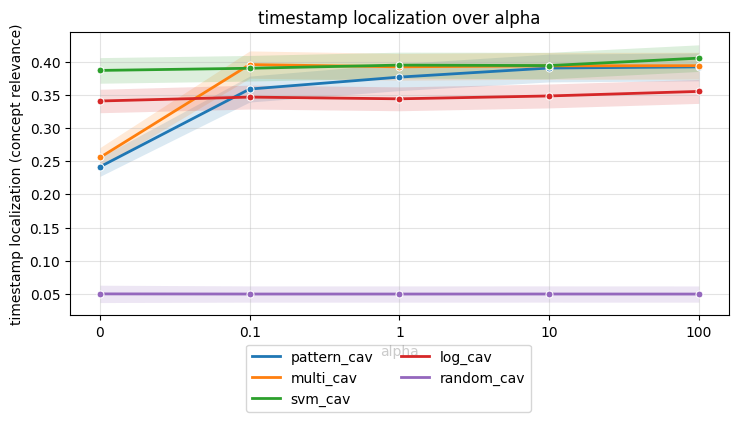

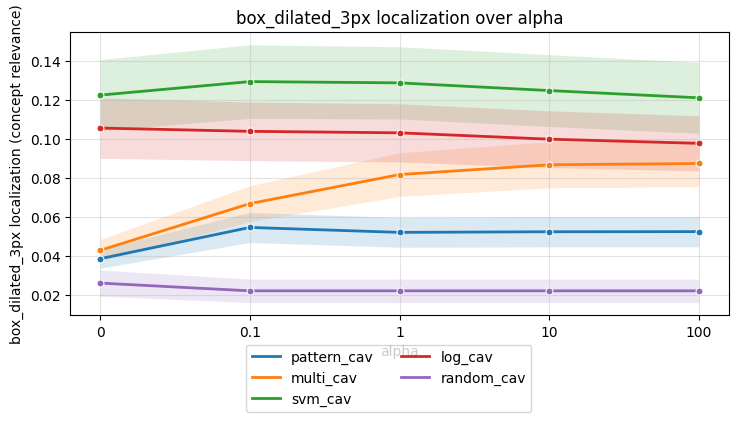

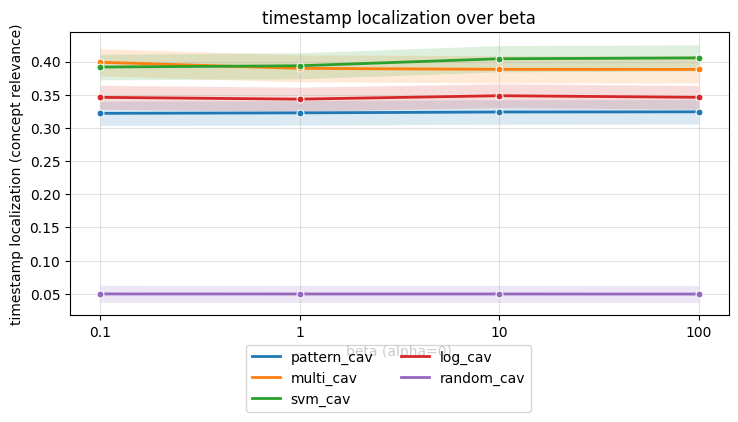

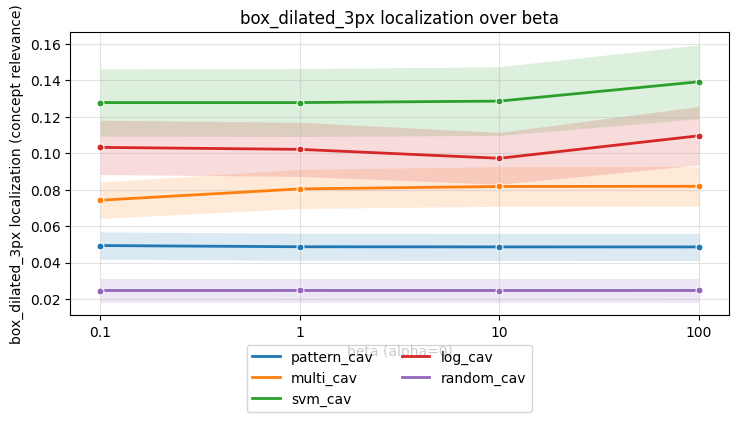

In [11]:
cav_types = ("pattern_cav", "multi_cav", "svm_cav", "log_cav", "random_cav")
alphas=(0., 0.1, 1., 10., 100.),
betas=(0.1, 1., 10., 100.),
targets=("timestamp", "box", "brightness"),
use_cleaned_cavs = False  # Set True after generating cleaned concept-alignment metrics.
model="vgg16"
layer="features.29"

plot_df_loc = plot_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=alphas,
    use_cleaned_cavs=use_cleaned_cavs,
)

plot_df_loc = plot_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="box_dilated_3px",
    alphas=alphas,
    use_cleaned_cavs=use_cleaned_cavs,
)

plot_df_loc = plot_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=(0., 0., 0., 0.),
    betas=betas,
    targets=targets,
    use_cleaned_cavs=use_cleaned_cavs,
)

plot_df_loc = plot_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="box_dilated_3px",
    alphas=(0., 0., 0., 0.),
    betas=betas,
    targets=targets,
    use_cleaned_cavs=use_cleaned_cavs,
)

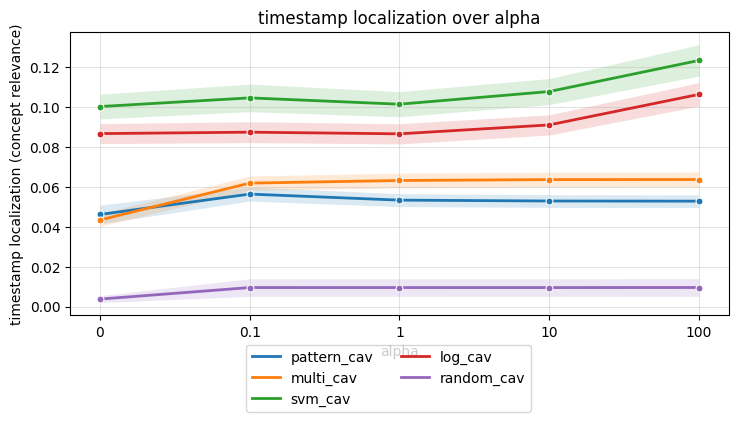

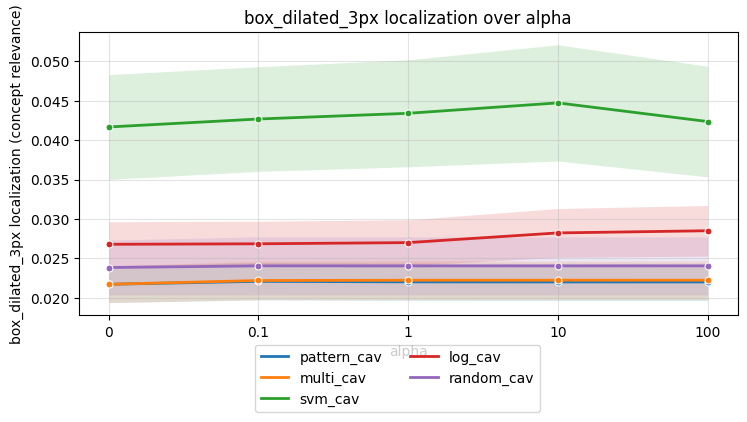

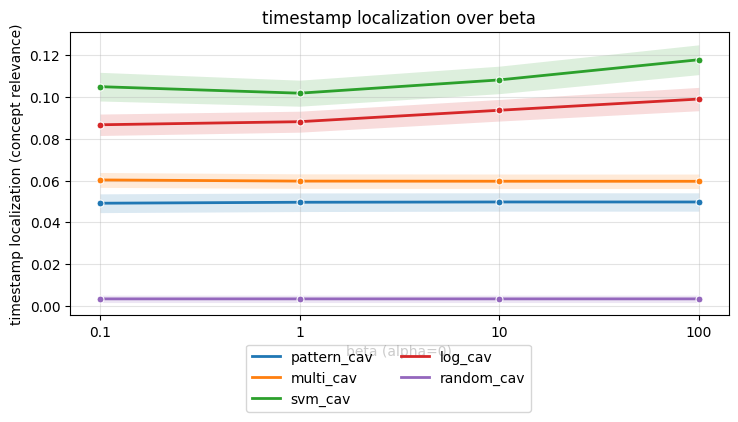

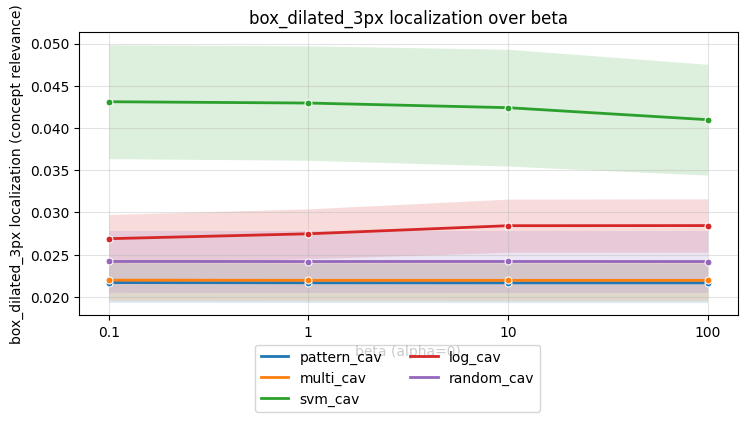

In [12]:
cav_types = ("pattern_cav", "multi_cav", "svm_cav", "log_cav", "random_cav")
alphas=(0., 0.1, 1., 10., 100.),
betas=(0.1, 1., 10., 100.),
targets=("timestamp", "box", "brightness"),
use_cleaned_cavs = False  # Set True after generating cleaned concept-alignment metrics.
model="resnet18"
layer="last_conv"

plot_df_loc = plot_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=alphas,
    use_cleaned_cavs=use_cleaned_cavs,
)

plot_df_loc = plot_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="box_dilated_3px",
    alphas=alphas,
    use_cleaned_cavs=use_cleaned_cavs,
)

plot_df_loc = plot_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=(0., 0., 0., 0.),
    betas=betas,
    targets=targets,
    use_cleaned_cavs=use_cleaned_cavs,
)

plot_df_loc = plot_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="box_dilated_3px",
    alphas=(0., 0., 0., 0.),
    betas=betas,
    targets=targets,
    use_cleaned_cavs=use_cleaned_cavs,
)

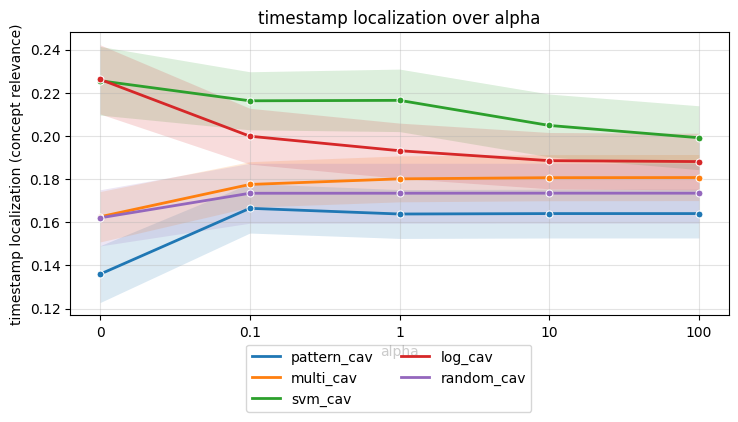

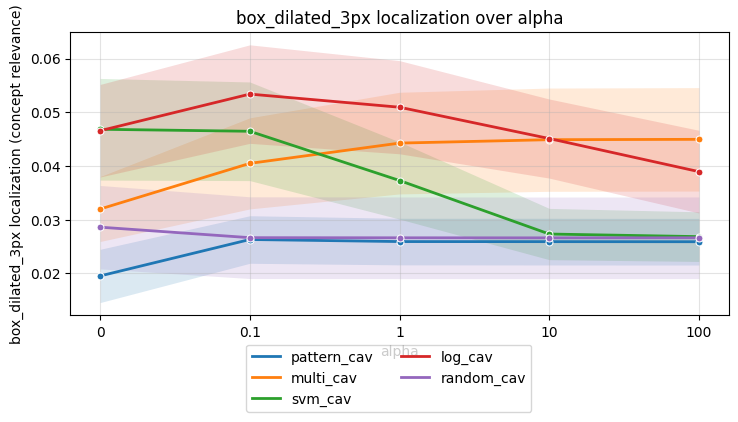

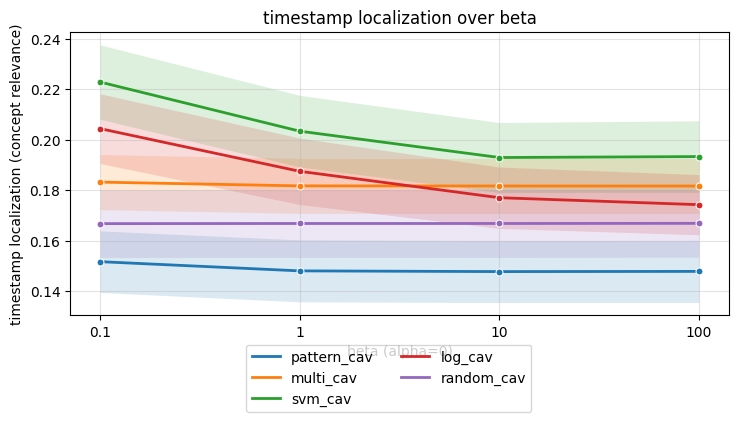

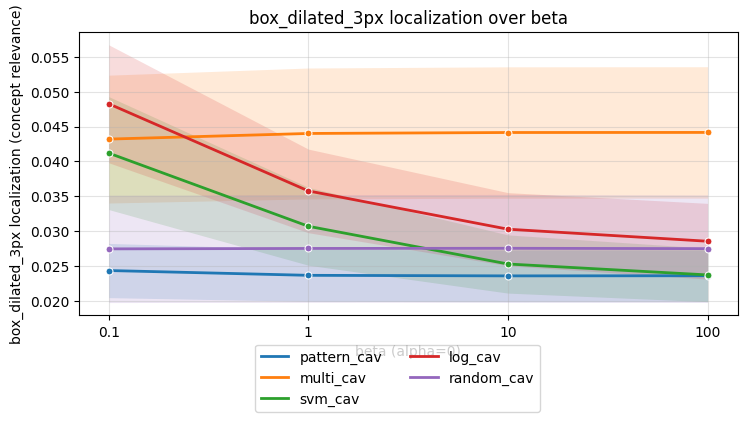

In [13]:
cav_types = ("pattern_cav", "multi_cav", "svm_cav", "log_cav", "random_cav")
alphas=(0., 0.1, 1., 10., 100.),
betas=(0.1, 1., 10., 100.),
targets=("timestamp", "box", "brightness"),
use_cleaned_cavs = False  # Set True after generating cleaned concept-alignment metrics.
model="vit_b_16"
layer="inspection_layer"

plot_df_loc = plot_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=alphas,
    use_cleaned_cavs=use_cleaned_cavs,
)

plot_df_loc = plot_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="box_dilated_3px",
    alphas=alphas,
    use_cleaned_cavs=use_cleaned_cavs,
)

plot_df_loc = plot_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=(0., 0., 0., 0.),
    betas=betas,
    targets=targets,
    use_cleaned_cavs=use_cleaned_cavs,
)

plot_df_loc = plot_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    cav_types=cav_types,
    artifact="box_dilated_3px",
    alphas=(0., 0., 0., 0.),
    betas=betas,
    targets=targets,
    use_cleaned_cavs=use_cleaned_cavs,
)

### Heatmaps

In [14]:
timestamp_box_ids = [14, 16, 30, 43, 48, 69, 76, 95, 99]
timestamp_no_box_ids = [80, 189, 191, 266, 302, 311, 313, 351, 358, 390]
no_timestamp_box_ids = [0, 2, 5, 7, 11, 56, 71, 79, 81, 97]

timestamp_sample_id = 80
box_sample_id = 0

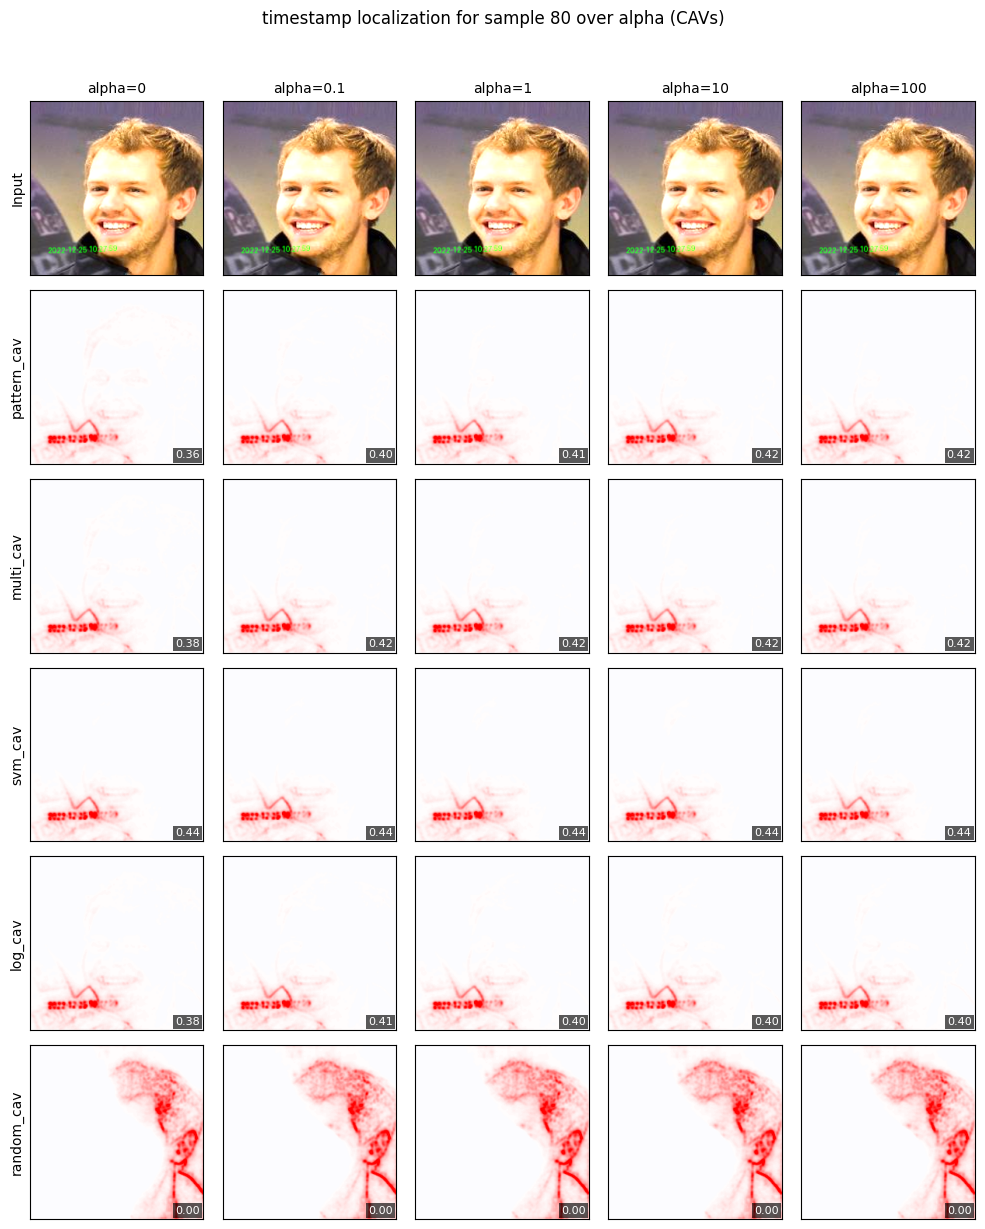

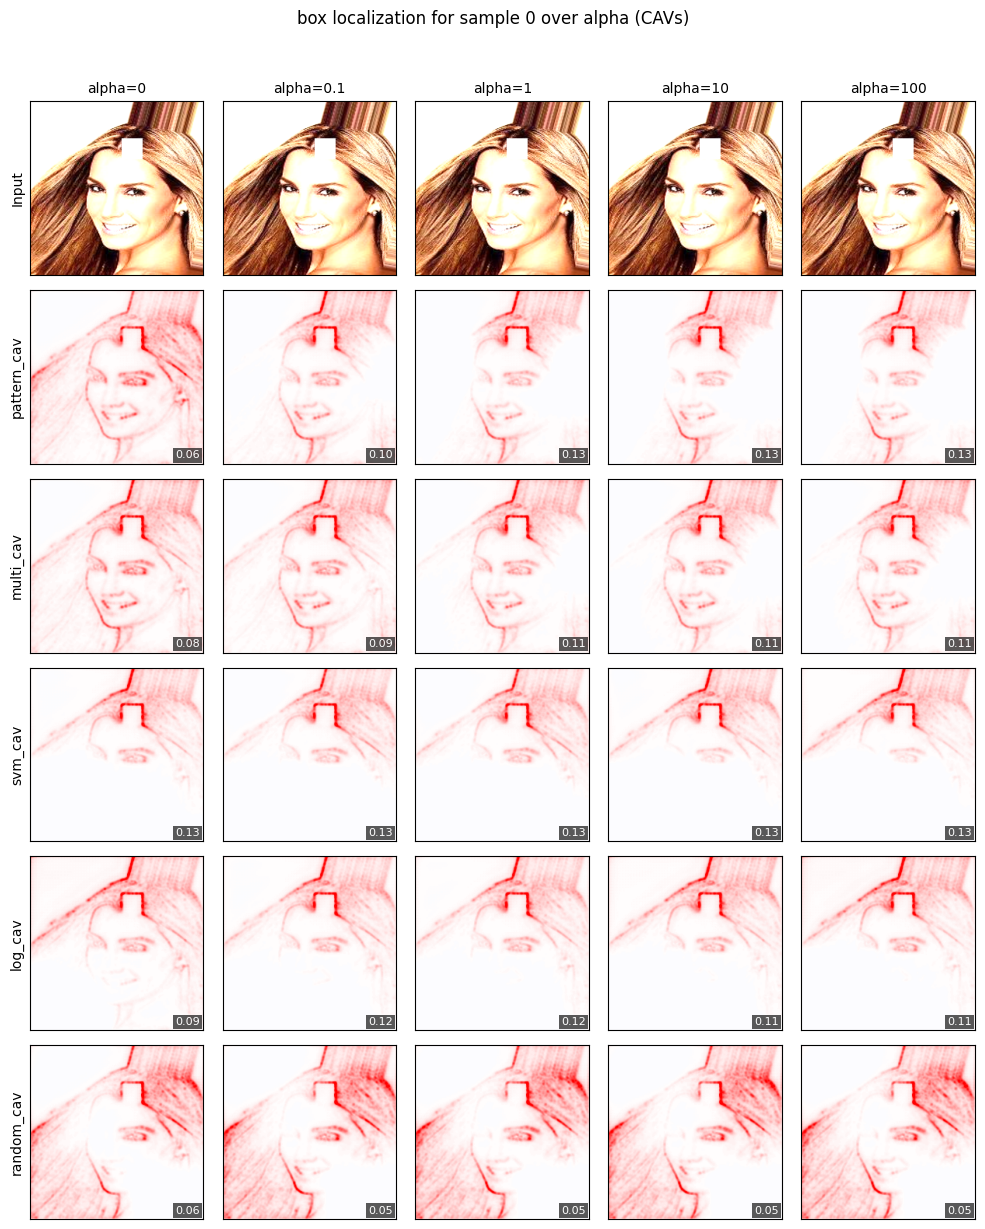

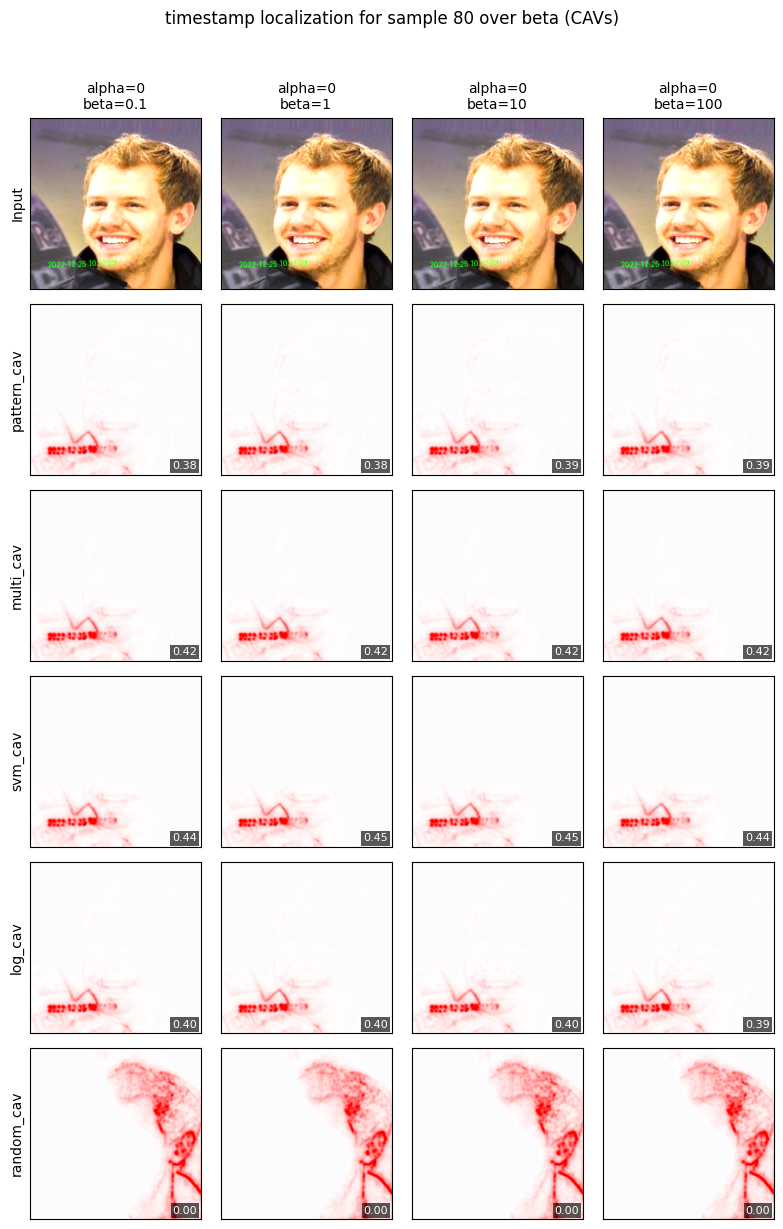

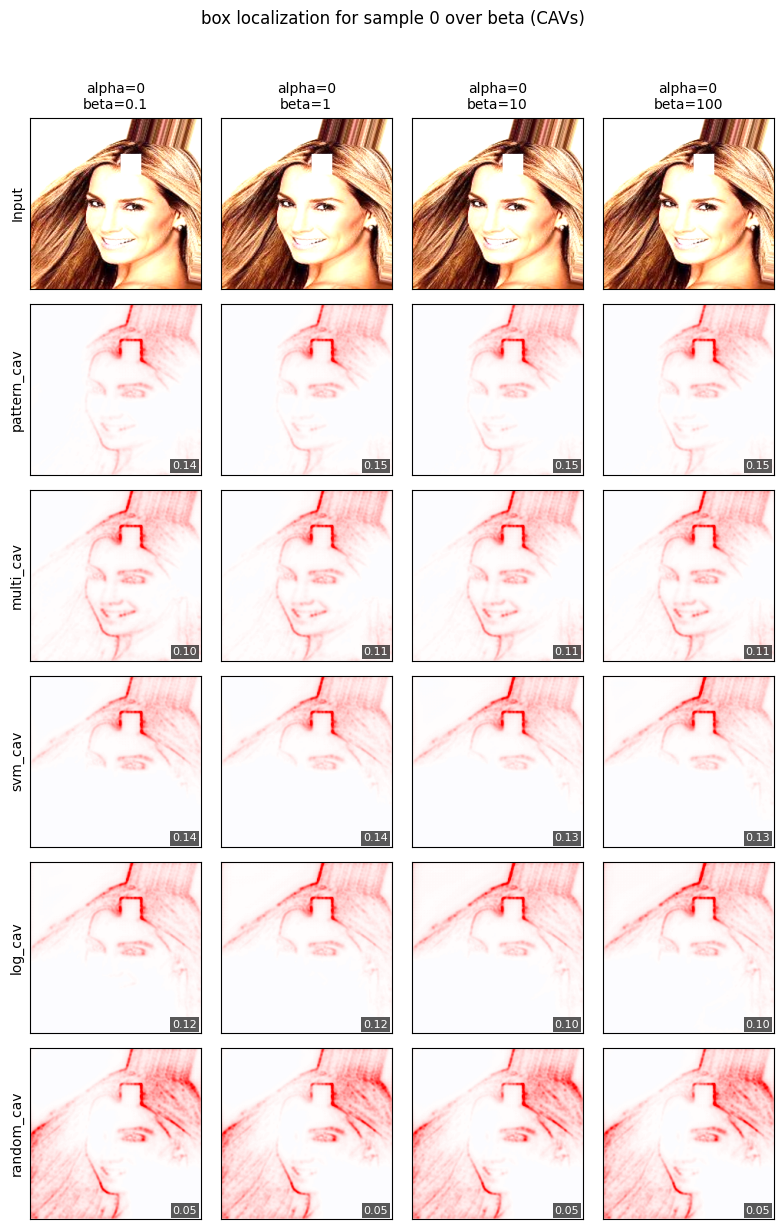

In [15]:
cav_types = ("pattern_cav", "multi_cav", "svm_cav", "log_cav", "random_cav")
alphas=(0, 0.1, 1., 10., 100.),
betas=(0.1, 1., 10., 100.),
targets=("timestamp", "box", "brightness"),
show_localization_scores = True
model="vgg16"
layer="features.29"

# Normal CAVs
_ = display_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    sample_id=timestamp_sample_id,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=alphas,
    targets=targets,
    heatmap_normalization="panel",
    use_cleaned_cavs=False,
    show_localization_scores=show_localization_scores,
)

_ = display_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    sample_id=box_sample_id,
    cav_types=cav_types,
    artifact="box",
    localization_score_artifact="box_dilated_3px",
    alphas=alphas,
    targets=targets,
    heatmap_normalization="panel",
    use_cleaned_cavs=False,
    show_localization_scores=show_localization_scores,
)


_ = display_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    sample_id=timestamp_sample_id,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=(0., 0., 0., 0.),
    betas=betas,
    targets=targets,
    heatmap_normalization="panel",
    use_cleaned_cavs=False,
    show_localization_scores=show_localization_scores,
)

_ = display_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    sample_id=box_sample_id,
    cav_types=cav_types,
    artifact="box",
    localization_score_artifact="box_dilated_3px",
    alphas=(0., 0., 0., 0.),
    betas=betas,
    targets=targets,
    heatmap_normalization="panel",
    use_cleaned_cavs=False,
    show_localization_scores=show_localization_scores,
)

# Cleaned CAVs
# _ = display_artifact_localization_over_alpha_beta(
#     model=model,
#     layer=layer,
#     sample_id=timestamp_sample_id,
#     cav_types=cav_types,
#     artifact="timestamp",
#     alphas=alphas,
#     targets=targets,
#     heatmap_normalization="panel",
#     use_cleaned_cavs=True,
#     show_localization_scores=show_localization_scores,
# )

# _ = display_artifact_localization_over_alpha_beta(
#     model=model,
#     layer=layer,
#     sample_id=box_sample_id,
#     cav_types=cav_types,
#     artifact="box",
#     localization_score_artifact="box_dilated_3px",
#     alphas=alphas,
#     targets=targets,
#     heatmap_normalization="panel",
#     use_cleaned_cavs=True,
#     show_localization_scores=show_localization_scores,
# )


# _ = display_artifact_localization_over_alpha_beta(
#     model=model,
#     layer=layer,
#     sample_id=timestamp_sample_id,
#     cav_types=cav_types,
#     artifact="timestamp",
#     alphas=(0., 0., 0., 0.),
#     betas=betas,
#     targets=targets,
#     heatmap_normalization="panel",
#     use_cleaned_cavs=True,
#     show_localization_scores=show_localization_scores,
# )

# _ = display_artifact_localization_over_alpha_beta(
#     model=model,
#     layer=layer,
#     sample_id=box_sample_id,
#     cav_types=cav_types,
#     artifact="box",
#     localization_score_artifact="box_dilated_3px",
#     alphas=(0., 0., 0., 0.),
#     betas=betas,
#     targets=targets,
#     heatmap_normalization="panel",
#     use_cleaned_cavs=True,
#     show_localization_scores=show_localization_scores,
# )

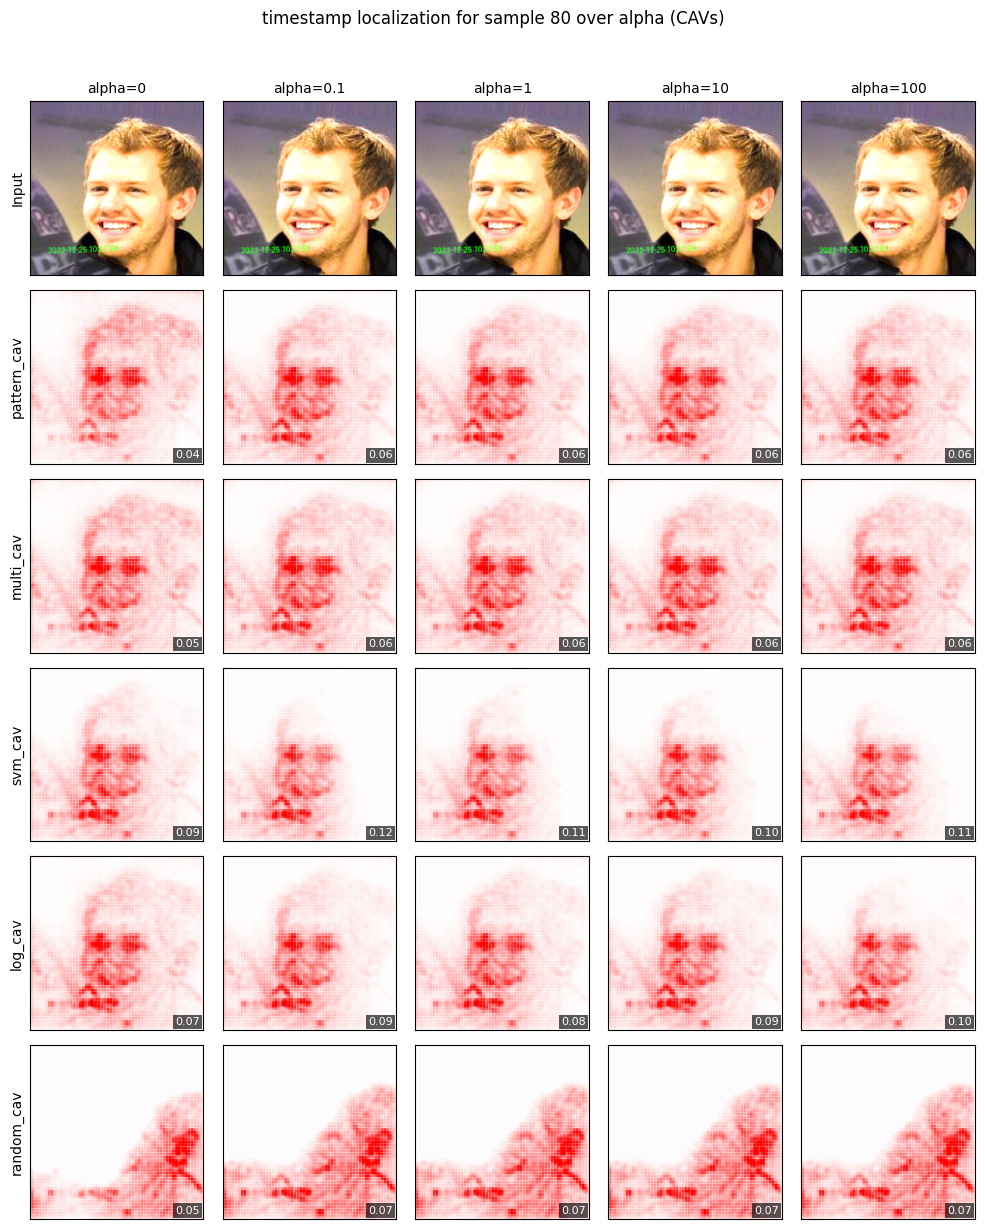

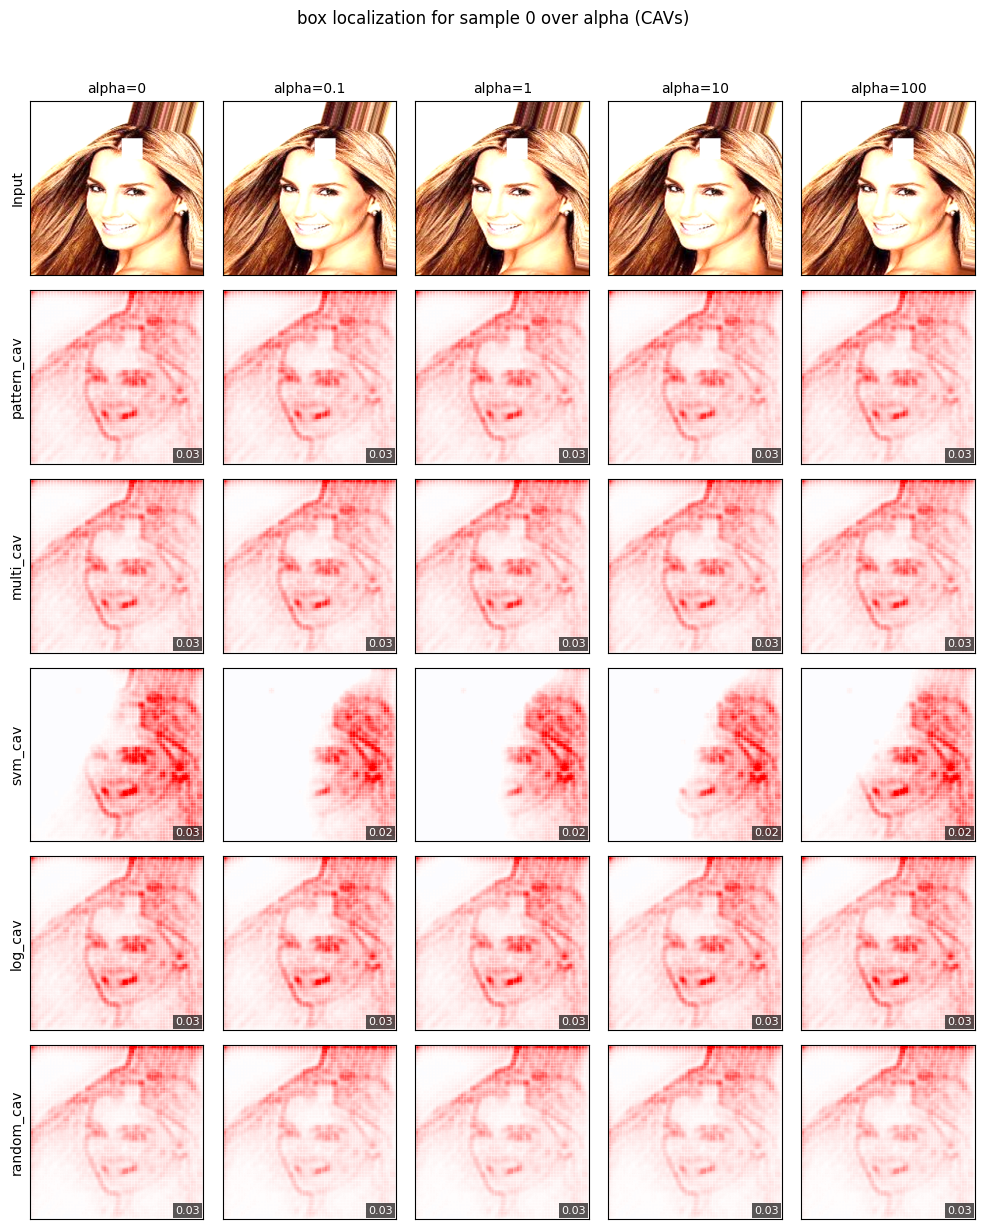

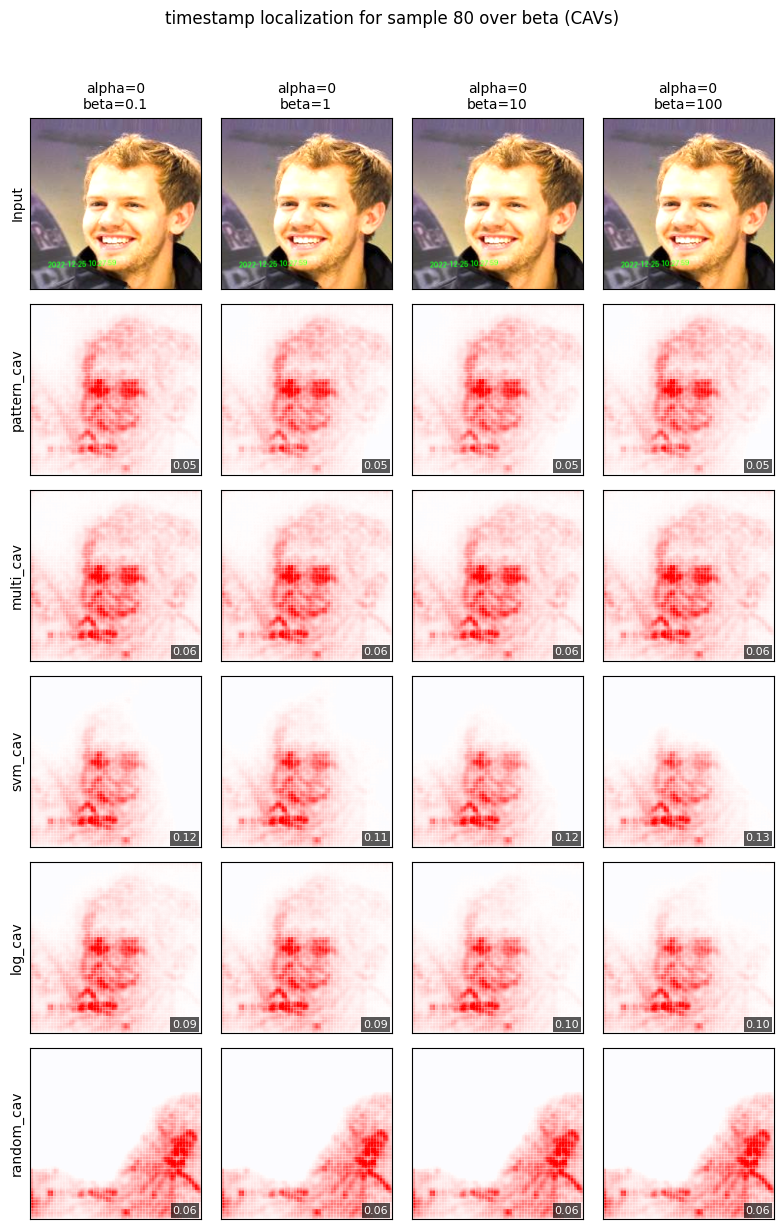

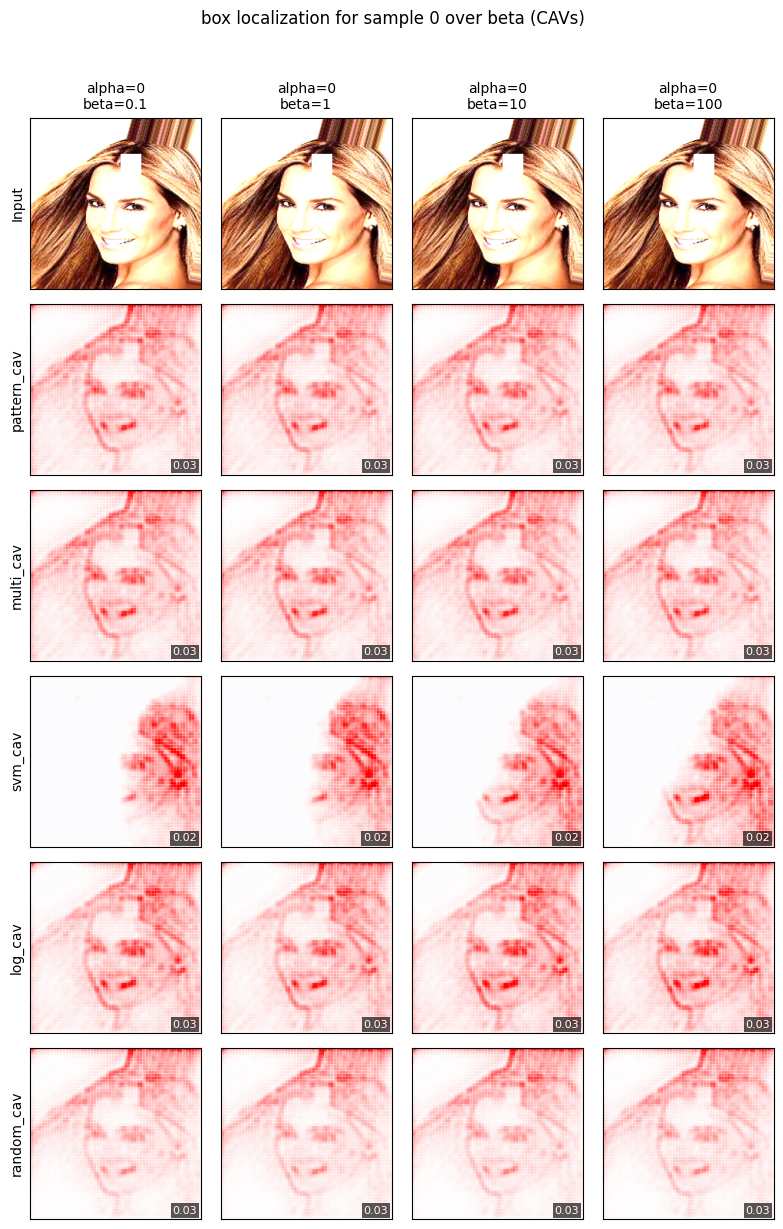

In [16]:
cav_types = ("pattern_cav", "multi_cav", "svm_cav", "log_cav", "random_cav")
alphas=(0, 0.1, 1., 10., 100.),
betas=(0.1, 1., 10., 100.),
targets=("timestamp", "box", "brightness"),
use_cleaned_cavs = False  # Set True after generating cleaned concept-alignment metrics.
show_localization_scores = True
model="resnet18"
layer="last_conv"

# Normal CAVs
_ = display_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    sample_id=timestamp_sample_id,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=alphas,
    targets=targets,
    heatmap_normalization="panel",
    use_cleaned_cavs=False,
    show_localization_scores=show_localization_scores,
)

_ = display_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    sample_id=box_sample_id,
    cav_types=cav_types,
    artifact="box",
    localization_score_artifact="box_dilated_3px",
    alphas=alphas,
    targets=targets,
    heatmap_normalization="panel",
    use_cleaned_cavs=False,
    show_localization_scores=show_localization_scores,
)


_ = display_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    sample_id=timestamp_sample_id,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=(0., 0., 0., 0.),
    betas=betas,
    targets=targets,
    heatmap_normalization="panel",
    use_cleaned_cavs=False,
    show_localization_scores=show_localization_scores,
)

_ = display_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    sample_id=box_sample_id,
    cav_types=cav_types,
    artifact="box",
    localization_score_artifact="box_dilated_3px",
    alphas=(0., 0., 0., 0.),
    betas=betas,
    targets=targets,
    heatmap_normalization="panel",
    use_cleaned_cavs=False,
    show_localization_scores=show_localization_scores,
)

# Cleaned CAVs
# _ = display_artifact_localization_over_alpha_beta(
#     model=model,
#     layer=layer,
#     sample_id=timestamp_sample_id,
#     cav_types=cav_types,
#     artifact="timestamp",
#     alphas=alphas,
#     targets=targets,
#     heatmap_normalization="panel",
#     use_cleaned_cavs=True,
#     show_localization_scores=show_localization_scores,
# )

# _ = display_artifact_localization_over_alpha_beta(
#     model=model,
#     layer=layer,
#     sample_id=box_sample_id,
#     cav_types=cav_types,
#     artifact="box",
#     localization_score_artifact="box_dilated_3px",
#     alphas=alphas,
#     targets=targets,
#     heatmap_normalization="panel",
#     use_cleaned_cavs=True,
#     show_localization_scores=show_localization_scores,
# )


# _ = display_artifact_localization_over_alpha_beta(
#     model=model,
#     layer=layer,
#     sample_id=timestamp_sample_id,
#     cav_types=cav_types,
#     artifact="timestamp",
#     alphas=(0., 0., 0., 0.),
#     betas=betas,
#     targets=targets,
#     heatmap_normalization="panel",
#     use_cleaned_cavs=True,
#     show_localization_scores=show_localization_scores,
# )

# _ = display_artifact_localization_over_alpha_beta(
#     model=model,
#     layer=layer,
#     sample_id=box_sample_id,
#     cav_types=cav_types,
#     artifact="box",
#     localization_score_artifact="box_dilated_3px",
#     alphas=(0., 0., 0., 0.),
#     betas=betas,
#     targets=targets,
#     heatmap_normalization="panel",
#     use_cleaned_cavs=True,
#     show_localization_scores=show_localization_scores,
# )

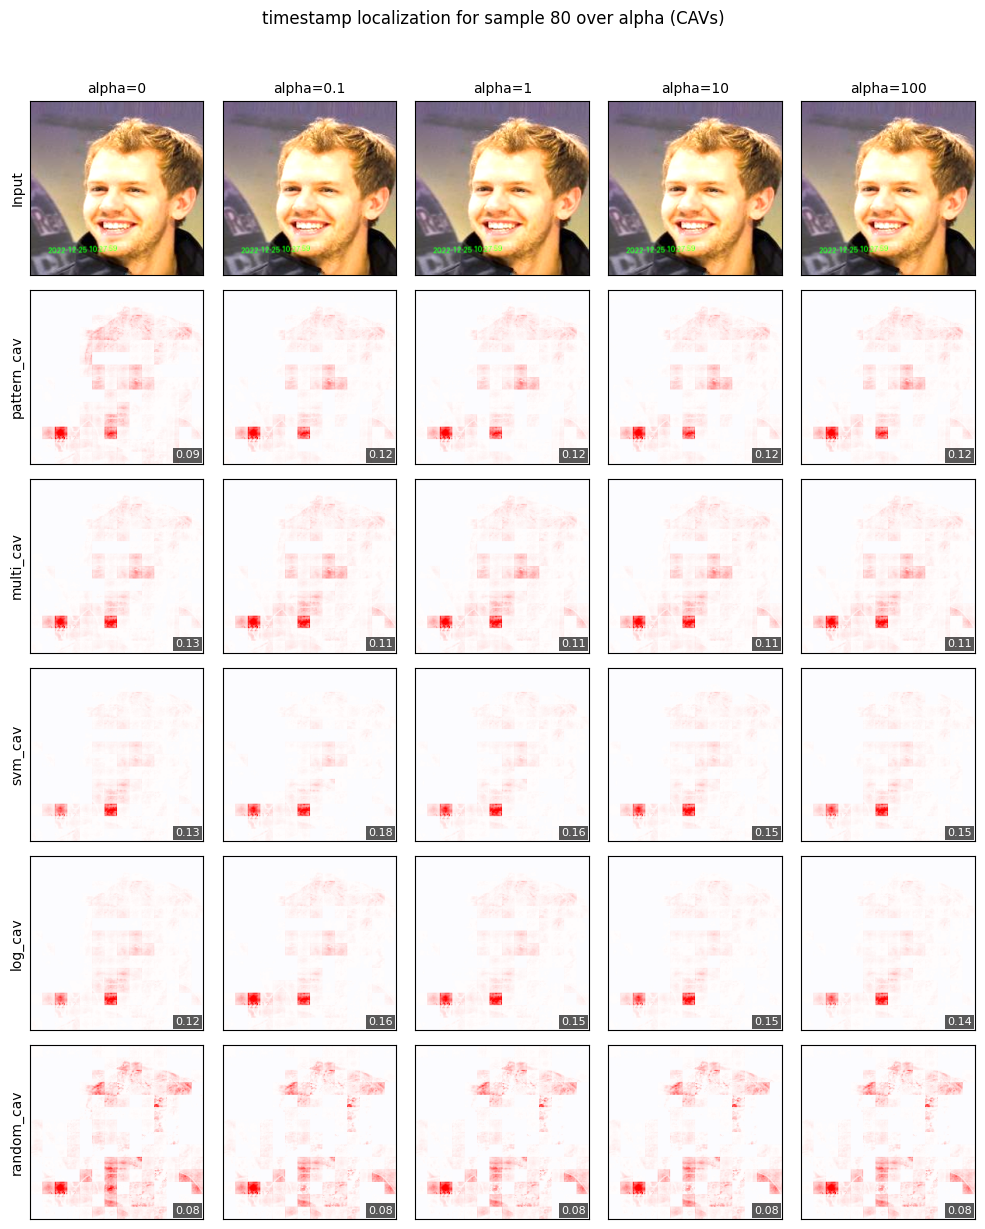

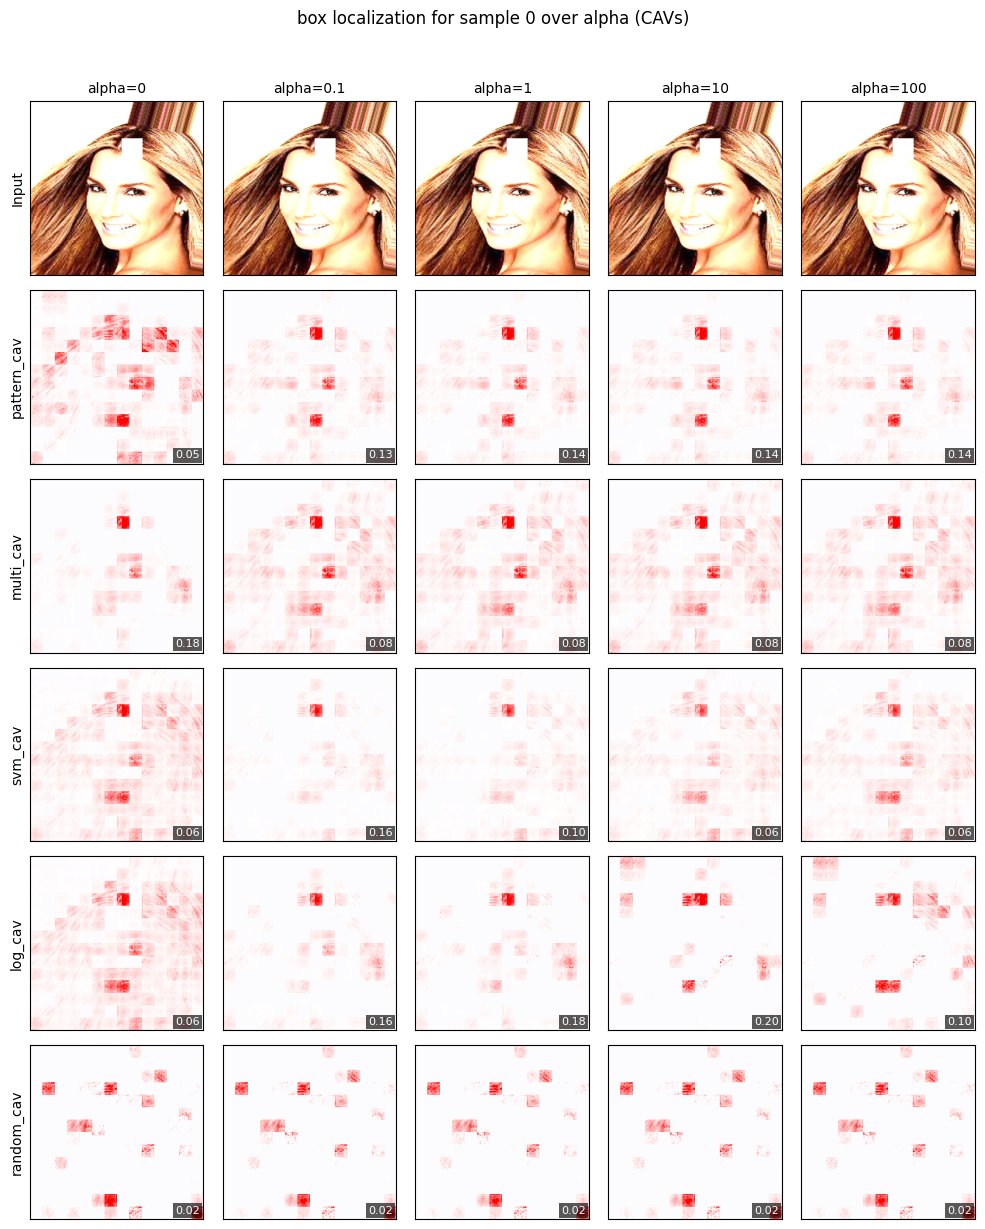

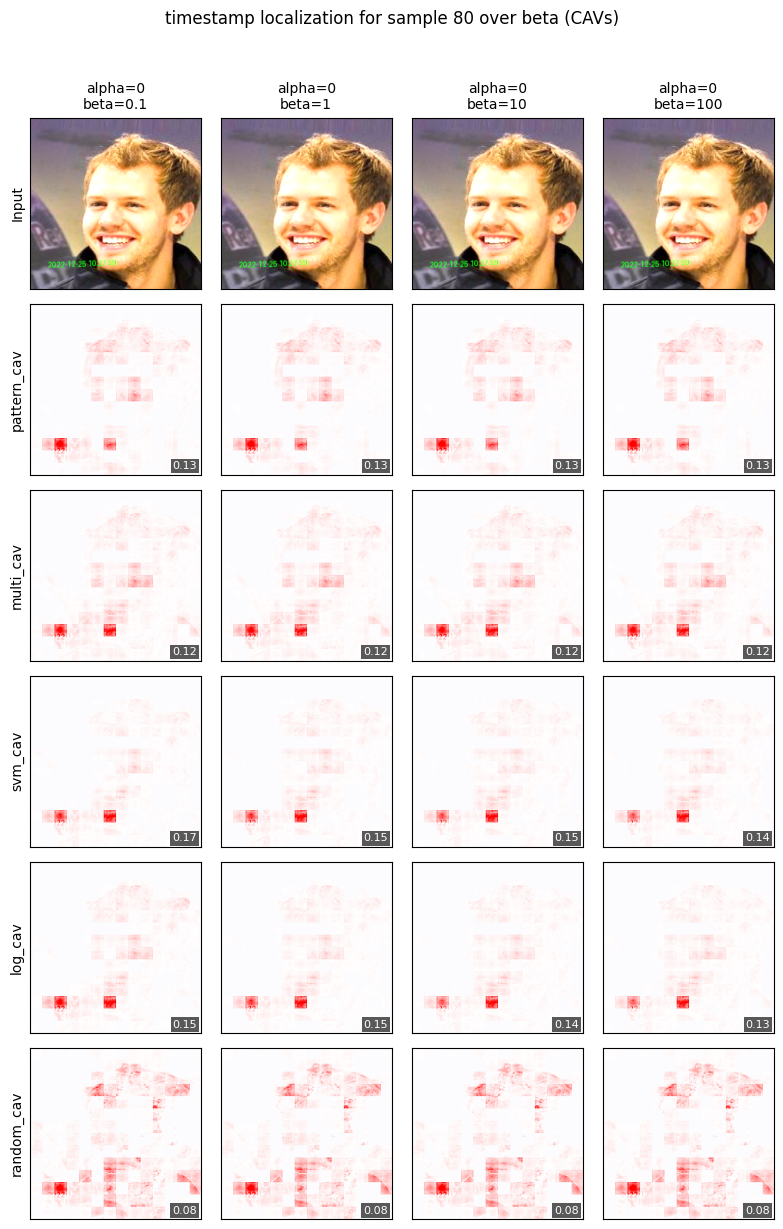

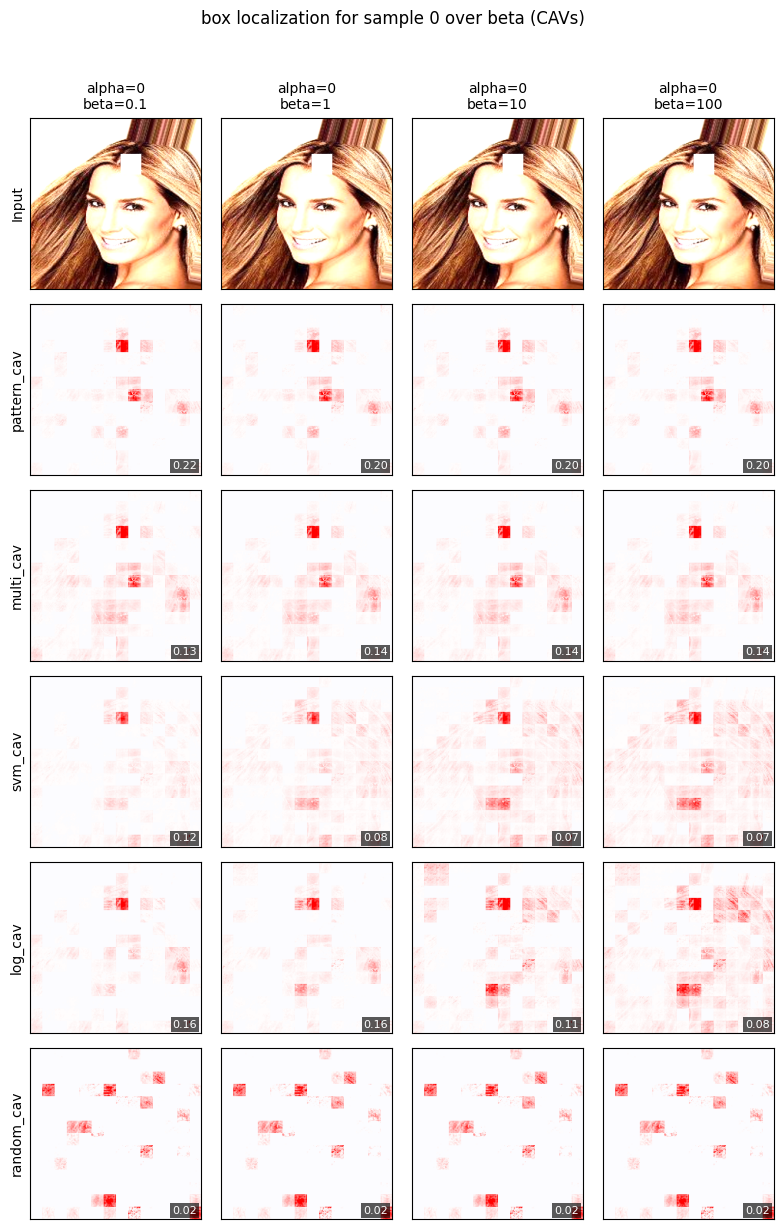

In [17]:
cav_types = ("pattern_cav", "multi_cav", "svm_cav", "log_cav", "random_cav")
alphas=(0, 0.1, 1., 10., 100.),
betas=(0.1, 1., 10., 100.),
targets=("timestamp", "box", "brightness"),
use_cleaned_cavs = True  # Set True after generating cleaned concept-alignment metrics.
show_localization_scores = True
model="vit_b_16"
layer="inspection_layer"

# Normal CAVs
_ = display_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    sample_id=timestamp_sample_id,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=alphas,
    targets=targets,
    heatmap_normalization="panel",
    use_cleaned_cavs=False,
    show_localization_scores=show_localization_scores,
)

_ = display_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    sample_id=box_sample_id,
    cav_types=cav_types,
    artifact="box",
    localization_score_artifact="box_dilated_3px",
    alphas=alphas,
    targets=targets,
    heatmap_normalization="panel",
    use_cleaned_cavs=False,
    show_localization_scores=show_localization_scores,
)


_ = display_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    sample_id=timestamp_sample_id,
    cav_types=cav_types,
    artifact="timestamp",
    alphas=(0., 0., 0., 0.),
    betas=betas,
    targets=targets,
    heatmap_normalization="panel",
    use_cleaned_cavs=False,
    show_localization_scores=show_localization_scores,
)

_ = display_artifact_localization_over_alpha_beta(
    model=model,
    layer=layer,
    sample_id=box_sample_id,
    cav_types=cav_types,
    artifact="box",
    localization_score_artifact="box_dilated_3px",
    alphas=(0., 0., 0., 0.),
    betas=betas,
    targets=targets,
    heatmap_normalization="panel",
    use_cleaned_cavs=False,
    show_localization_scores=show_localization_scores,
)

# Cleaned CAVs
# _ = display_artifact_localization_over_alpha_beta(
#     model=model,
#     layer=layer,
#     sample_id=timestamp_sample_id,
#     cav_types=cav_types,
#     artifact="timestamp",
#     alphas=alphas,
#     targets=targets,
#     heatmap_normalization="panel",
#     use_cleaned_cavs=True,
#     show_localization_scores=show_localization_scores,
# )

# _ = display_artifact_localization_over_alpha_beta(
#     model=model,
#     layer=layer,
#     sample_id=box_sample_id,
#     cav_types=cav_types,
#     artifact="box",
#     localization_score_artifact="box_dilated_3px",
#     alphas=alphas,
#     targets=targets,
#     heatmap_normalization="panel",
#     use_cleaned_cavs=True,
#     show_localization_scores=show_localization_scores,
# )


# _ = display_artifact_localization_over_alpha_beta(
#     model=model,
#     layer=layer,
#     sample_id=timestamp_sample_id,
#     cav_types=cav_types,
#     artifact="timestamp",
#     alphas=(0., 0., 0., 0.),
#     betas=betas,
#     targets=targets,
#     heatmap_normalization="panel",
#     use_cleaned_cavs=True,
#     show_localization_scores=show_localization_scores,
# )

# _ = display_artifact_localization_over_alpha_beta(
#     model=model,
#     layer=layer,
#     sample_id=box_sample_id,
#     cav_types=cav_types,
#     artifact="box",
#     localization_score_artifact="box_dilated_3px",
#     alphas=(0., 0., 0., 0.),
#     betas=betas,
#     targets=targets,
#     heatmap_normalization="panel",
#     use_cleaned_cavs=True,
#     show_localization_scores=show_localization_scores,
# )

In [14]:
# common_cav_types = ("pattern_cav", "multi_cav", "svm_cav", "log_cav", "random_cav")
# alphas=(0., 0., 0., 0.),
# betas=(0.1, 1., 10., 100.),
# targets=("timestamp", "box", "brightness"),

# plot_df_iou = plot_artifact_localization_over_alpha_beta(
#     cav_types=common_cav_types,
#     artifact="timestamp",
#     alphas=common_alphas,
#     metric_prefix="iou",
#     value_column="iou",
#     metric_name="IoU",
#     ylabel_template="{artifact} localization (IoU)",
#     title_template="{artifact} IoU over alpha",
#     save_name_template="{artifact}_iou_over_alpha_line",
# )

# plot_df_iou_box = plot_artifact_localization_over_alpha_beta(
#     cav_types=common_cav_types,
#     artifact="box",
#     alphas=common_alphas,
#     metric_prefix="iou",
#     value_column="iou",
#     metric_name="IoU",
#     ylabel_template="{artifact} localization (IoU)",
#     title_template="{artifact} IoU over alpha",
#     save_name_template="{artifact}_iou_over_alpha_line",
# )

# plot_df_intersection_over_true_mask = plot_artifact_localization_over_alpha_beta(
#     cav_types=common_cav_types,
#     artifact="timestamp",
#     alphas=common_alphas,
#     metric_prefix="intersection_over_true_mask",
#     value_column="intersection_over_true_mask",
#     metric_name="intersection over true mask",
#     ylabel_template="{artifact} localization (intersection over true mask)",
#     title_template="{artifact} intersection over true mask over alpha",
#     save_name_template="{artifact}_intersection_over_true_mask_over_alpha_line",
# )

# plot_df_intersection_over_true_mask_box = plot_artifact_localization_over_alpha_beta(
#     cav_types=common_cav_types,
#     artifact="box",
#     alphas=common_alphas,
#     metric_prefix="intersection_over_true_mask",
#     value_column="intersection_over_true_mask",
#     metric_name="intersection over true mask",
#     ylabel_template="{artifact} localization (intersection over true mask)",
#     title_template="{artifact} intersection over true mask over alpha",
#     save_name_template="{artifact}_intersection_over_true_mask_over_alpha_line",
# )
